In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [4]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 42  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 42

## Step 0: Get loaded data #CHANGE DIRECTORIES FOR CELL DATA

In [5]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [6]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

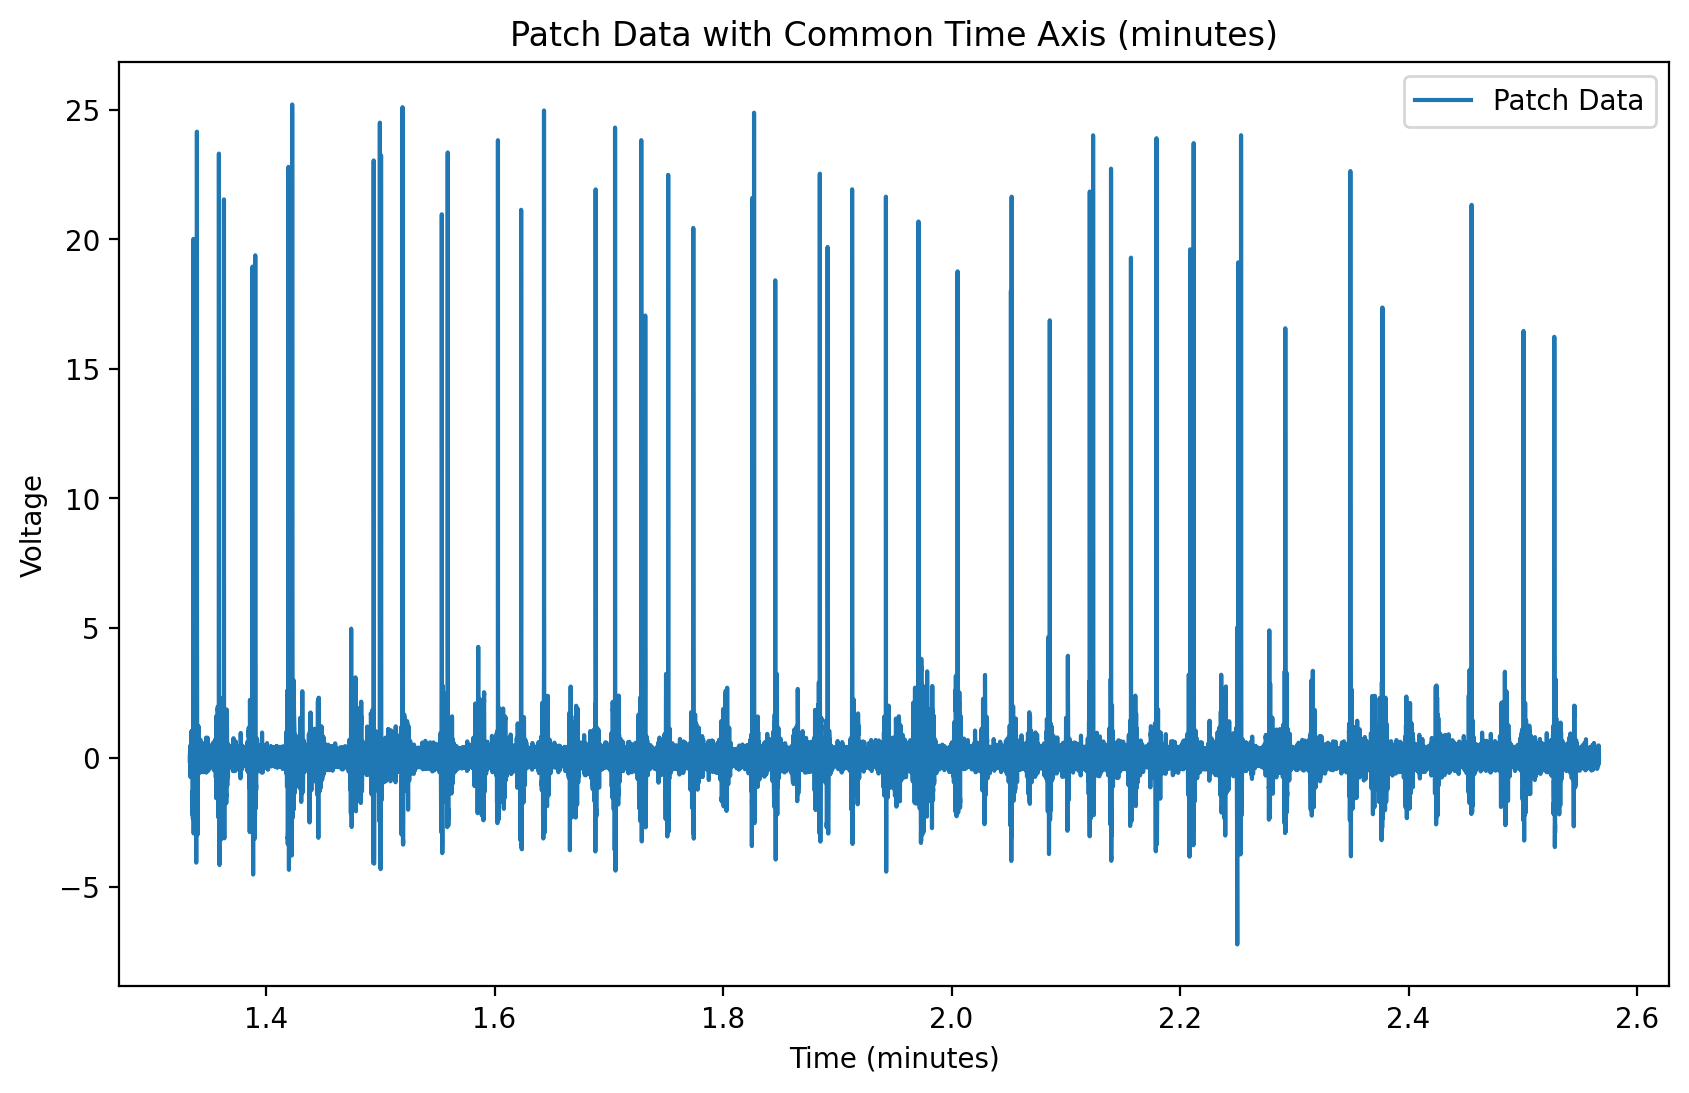

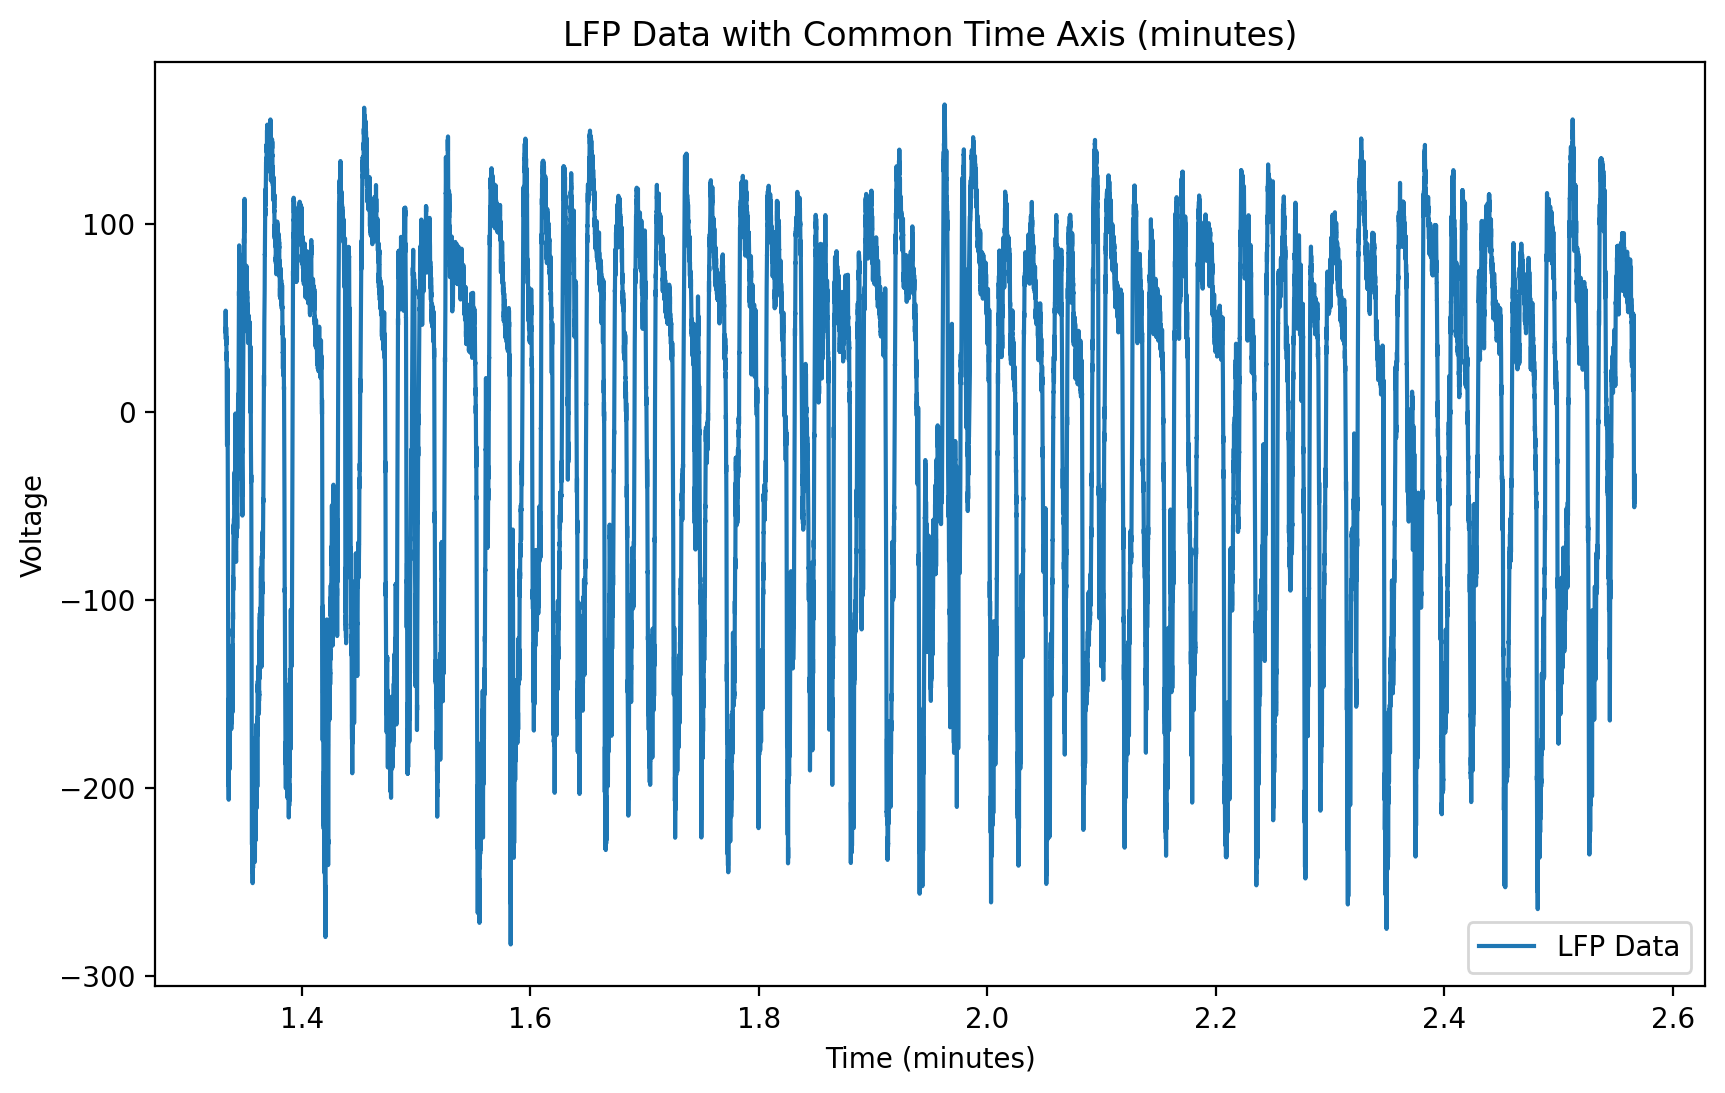

In [7]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: ANALYZE LFP DATA BY WINDOWS

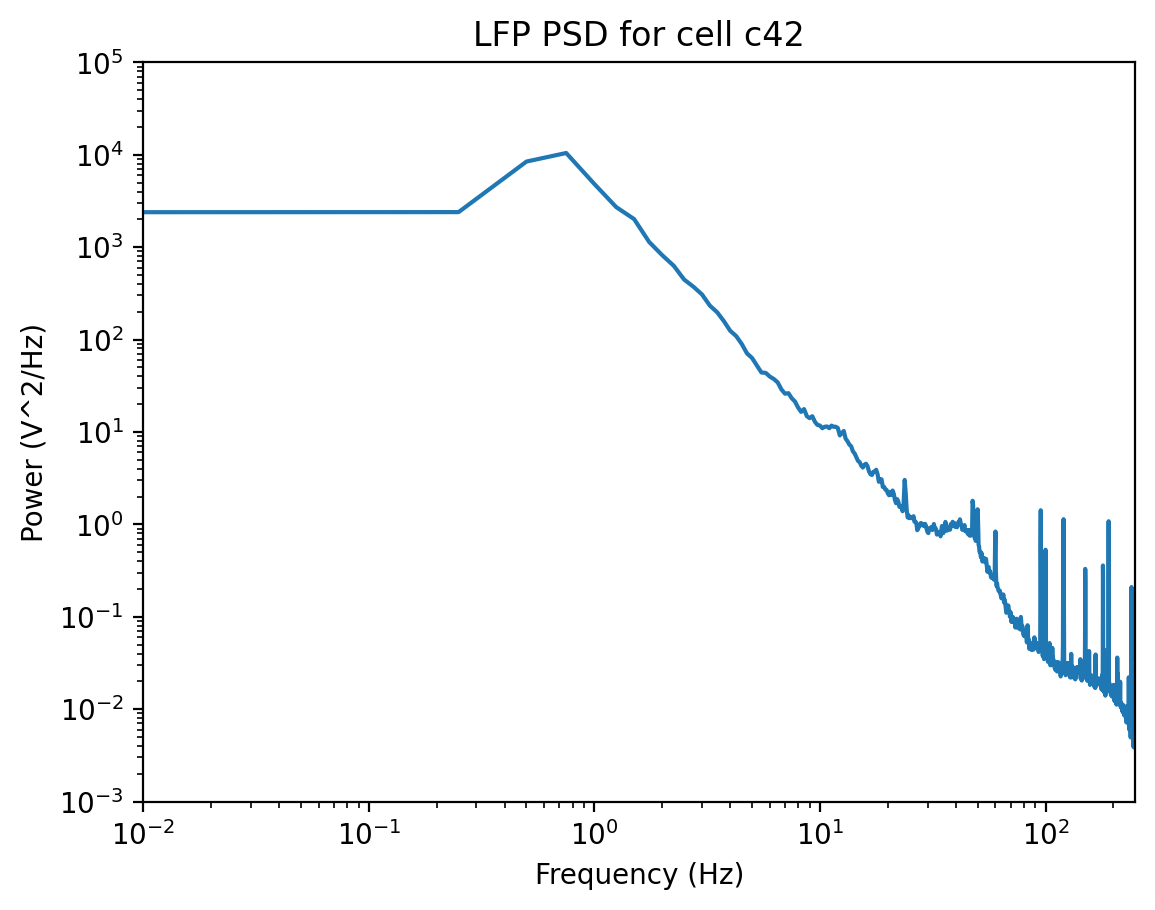

In [8]:
# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


In [9]:
bands = Bands({'gamma' : [30, 55]})

In [353]:
decim_factor = 10

###### SLIDING WINDOWS APPROACH - Multitaper

In [358]:
model_mt, freqs_mt, window_times_mt = compute_lfp_windows(
    lfp_signal=lfp_filt,
    window_length_sec = 0.1,
    fs=lfp_fs,
    method="multitaper",
    decim_factor = decim_factor
)

summary_df_multitaper = model_mt.to_df()

Running group fits.: 100%|████████████| 202509/202509 [3:48:04<00:00, 14.80it/s]


In [359]:
#save as pickle
with open('mtc42_model_mt_shortwin.pkl', 'wb') as file:
    pickle.dump(model_mt, file)

with open('mtc42_freqs_mt_shortwin.pkl', 'wb') as file:
    pickle.dump(freqs_mt, file)

with open('mtc42_window_times_mt_shortwin.pkl', 'wb') as file:
    pickle.dump(window_times_mt, file)

In [360]:
#open pickle
with open('mtc42_model_mt_shortwin.pkl', 'rb') as file:
    model_mt = pickle.load(file)

with open('mtc42_freqs_mt_shortwin.pkl', 'rb') as file:
    freqs_mt = pickle.load(file)

with open('mtc42_window_times_mt_shortwin.pkl', 'rb') as file:
    window_times_mt = pickle.load(file)

                                                                                                  
                                           TIME RESULTS                                           
                                                                                                  
                                Number of time windows fit: 202509                                
                                                                                                  
                        The model was run on the frequency range 1 - 90 Hz                        
                                 Frequency Resolution is 0.35 Hz                                  
                                                                                                  
                              Power spectra were fit without a knee.                              
                                                                                                  
          

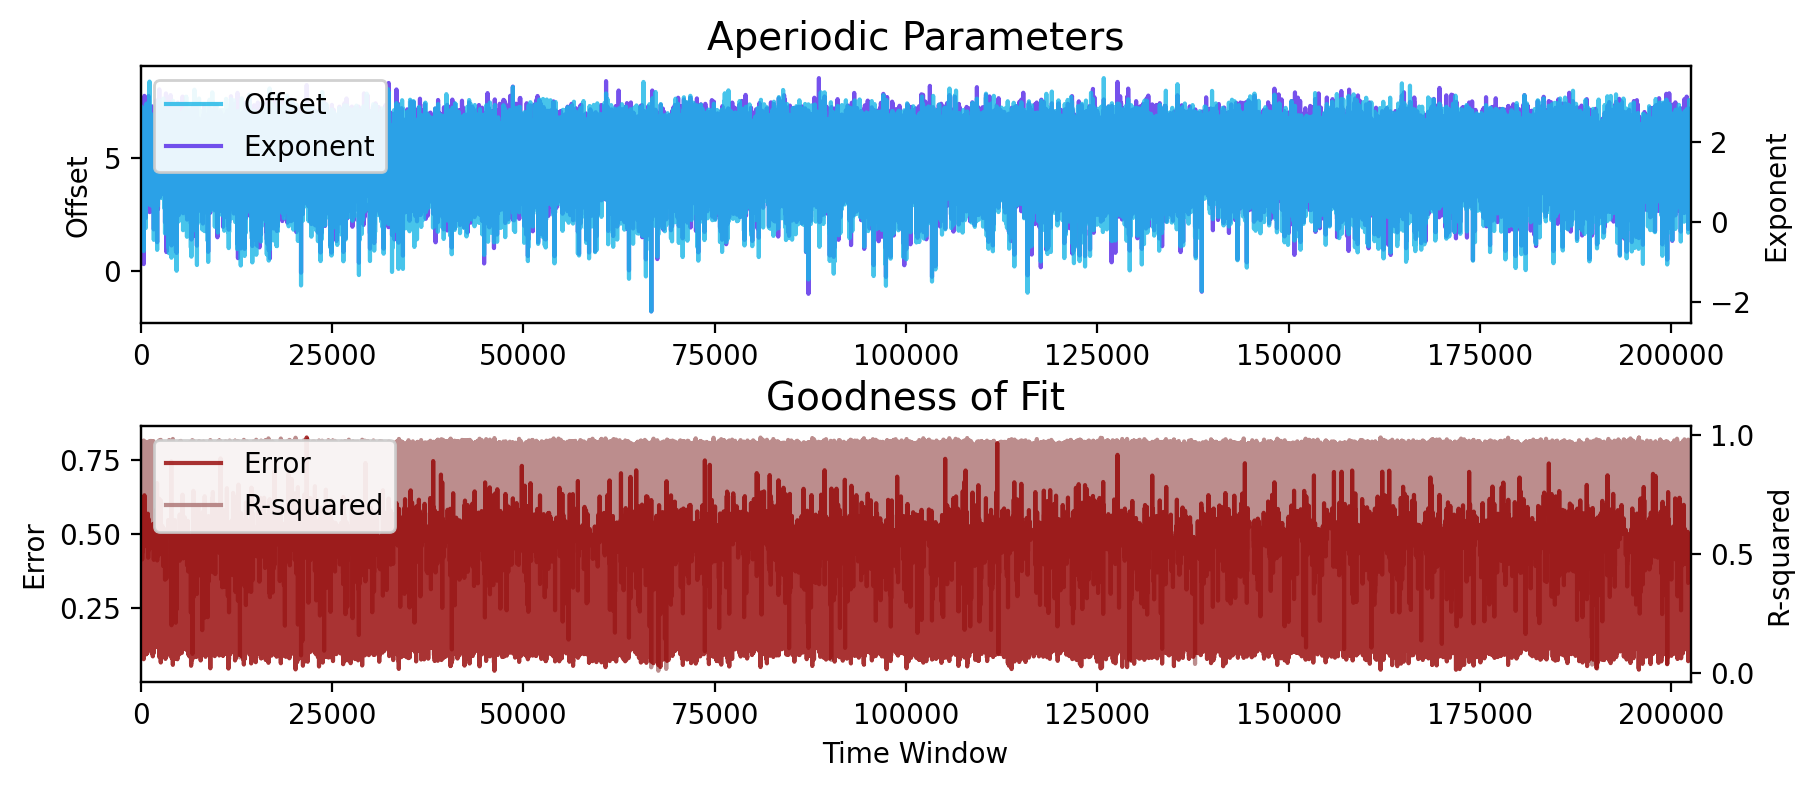

In [363]:
model_mt.print_results(
)
model_mt.plot(peak_org=bands)

In [364]:
# Existing summary from specparam (offset, exponent, r_squared, error, n_peaks, etc.)
summary_df_multitaper = model_mt.to_df().reset_index(drop=True)



In [365]:
summary_df_multitaper

,offset,exponent,error,r_squared
0,5.596020,1.534292,0.126576,0.958422
1,5.620008,1.567168,0.124111,0.961701
2,5.626757,1.582671,0.135697,0.954714
3,5.713627,1.674320,0.124594,0.964855
4,5.739174,1.668751,0.122620,0.962657
...,...,...,...,...
202504,4.635320,1.499339,0.365881,0.778033
202505,4.530012,1.545855,0.242479,0.881734
202506,4.649404,1.631111,0.279000,0.875492
202507,4.718734,1.662930,0.223579,0.908807


## STEP 2: Get AUC gamma (subtract off the aperiodic exponent from the raw spectrum)

In [366]:
#compute gamma AUC + exponent per window 
specp_auc_df = gamma_auc_and_exponent_per_window(model_mt, band=(25, 60), space="log")

Computing gamma AUC + exponent:   0%|          | 0/202509 [00:00<?, ?it/s]

In [367]:
specp_auc_df

,win_idx,gamma_auc,aperiodic_exponent
0,0,6.989696,1.534292
1,1,8.303400,1.567168
2,2,8.821492,1.582671
3,3,11.025683,1.674320
4,4,5.971059,1.668751
...,...,...,...
202504,202504,7.886624,1.499339
202505,202505,20.484263,1.545855
202506,202506,18.374256,1.631111
202507,202507,15.226729,1.662930


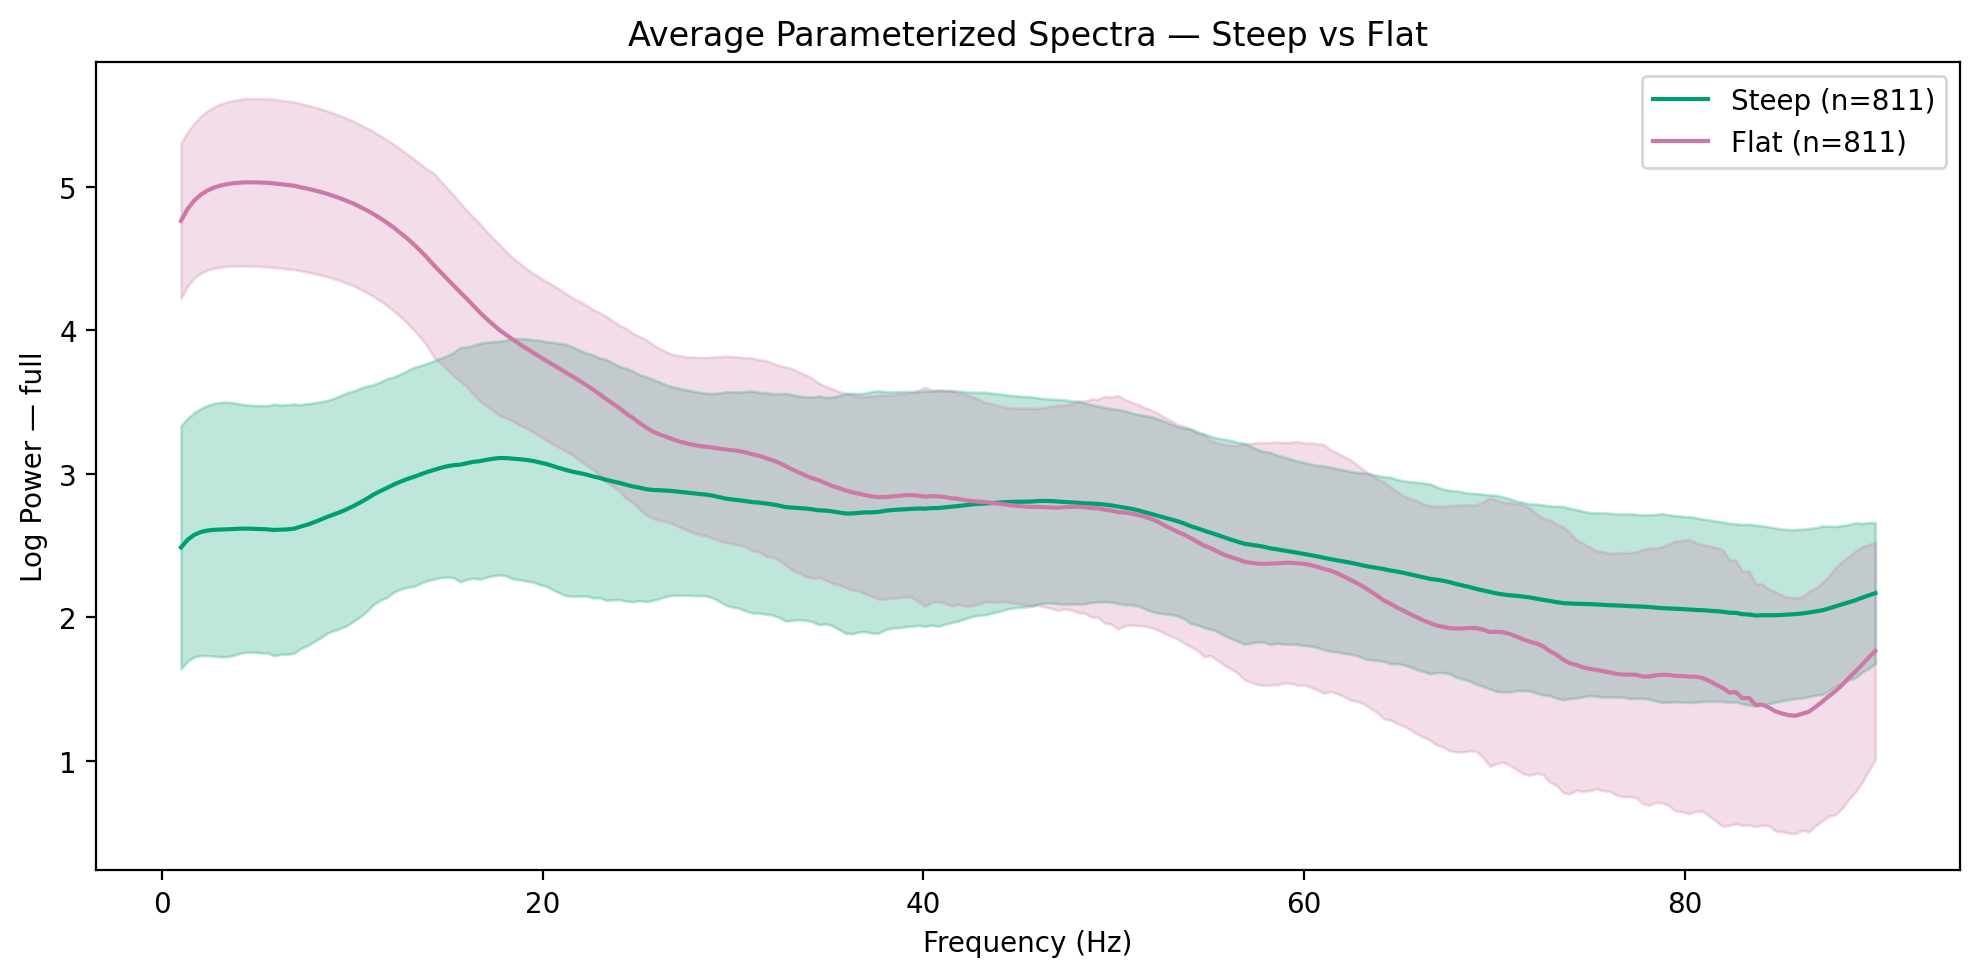

In [393]:
#plot average spectra for steep vs flat windows 
plot_param_spectra_two_groups(
    model_mt,
    group_a=blocks_steep_sec,  # steep
    group_b=blocks_flat_sec,   # flat
    window_times=window_times_mt,
    label_a="Steep", label_b="Flat",
    component="full", space="log",
    freq_range=(1, 150),
    ci="sd",
    lfp_fs=lfp_fs,             # needed for blocks in seconds
    title="Average Parameterized Spectra — Steep vs Flat",
)


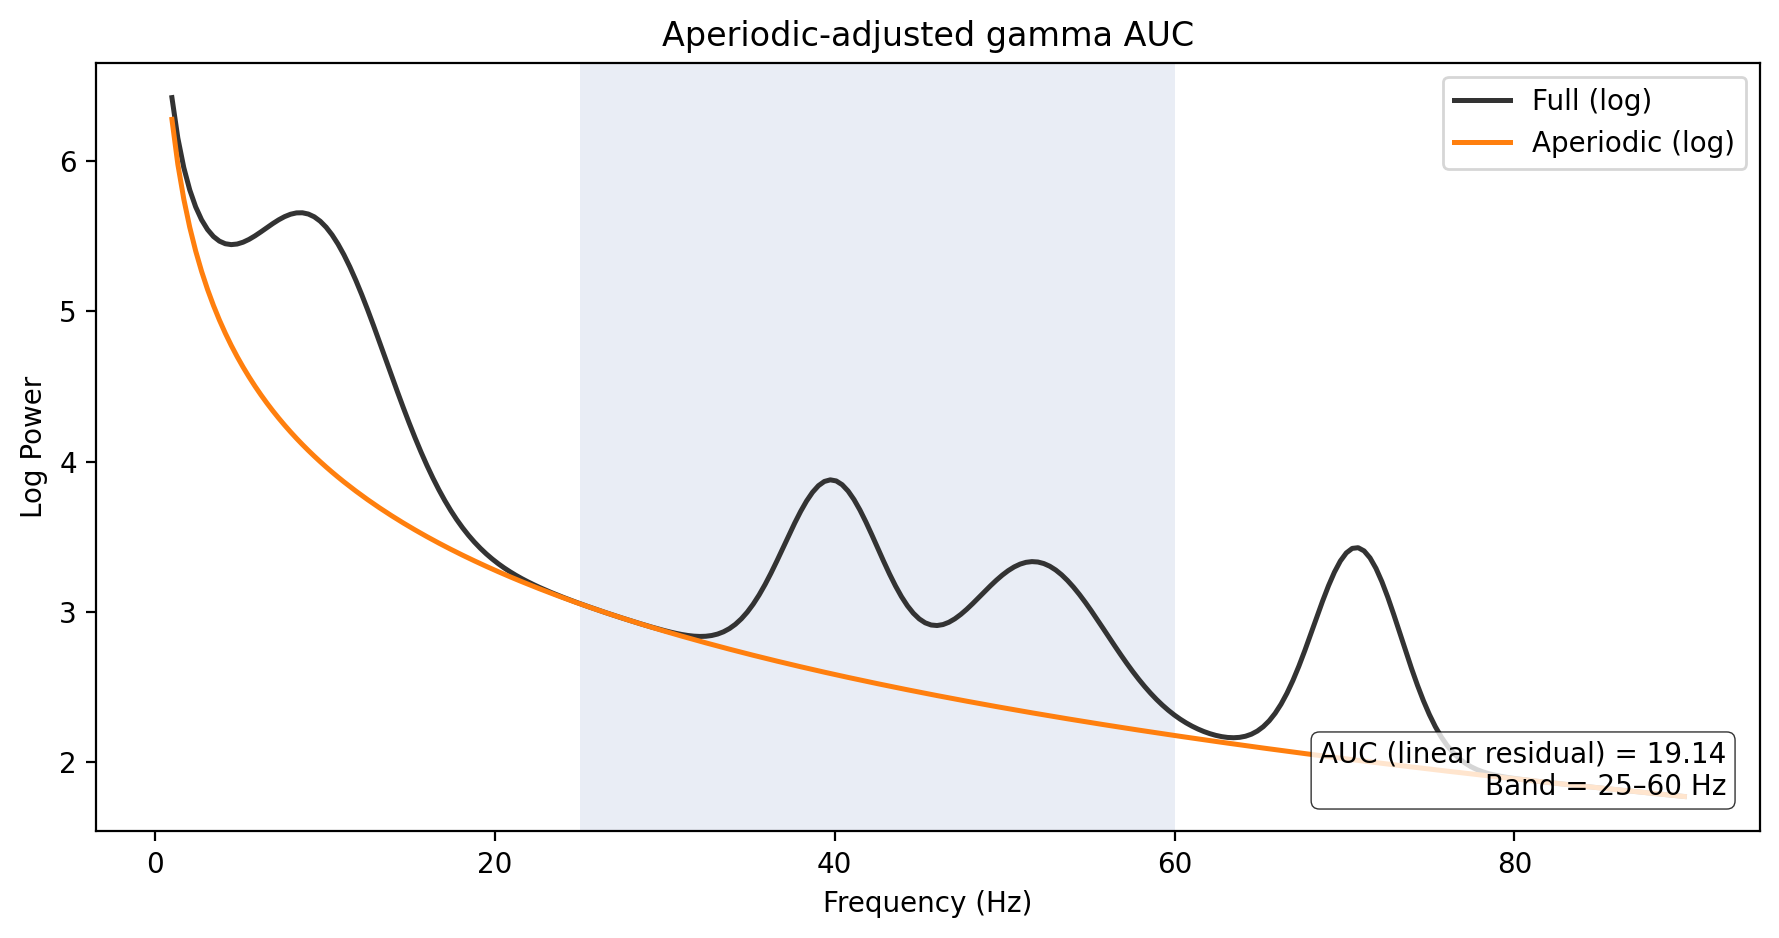

In [390]:
#Show example of process for one window idx
auc_val = plot_log_spectra_and_auc(
    model_mt,
    win_idx=20504,
    band=(25, 60),
    freq_range=(1, 90),   # optional, for display only
    title="Aperiodic-adjusted gamma AUC"
)


## STEP 3: Detect spikes from patch data

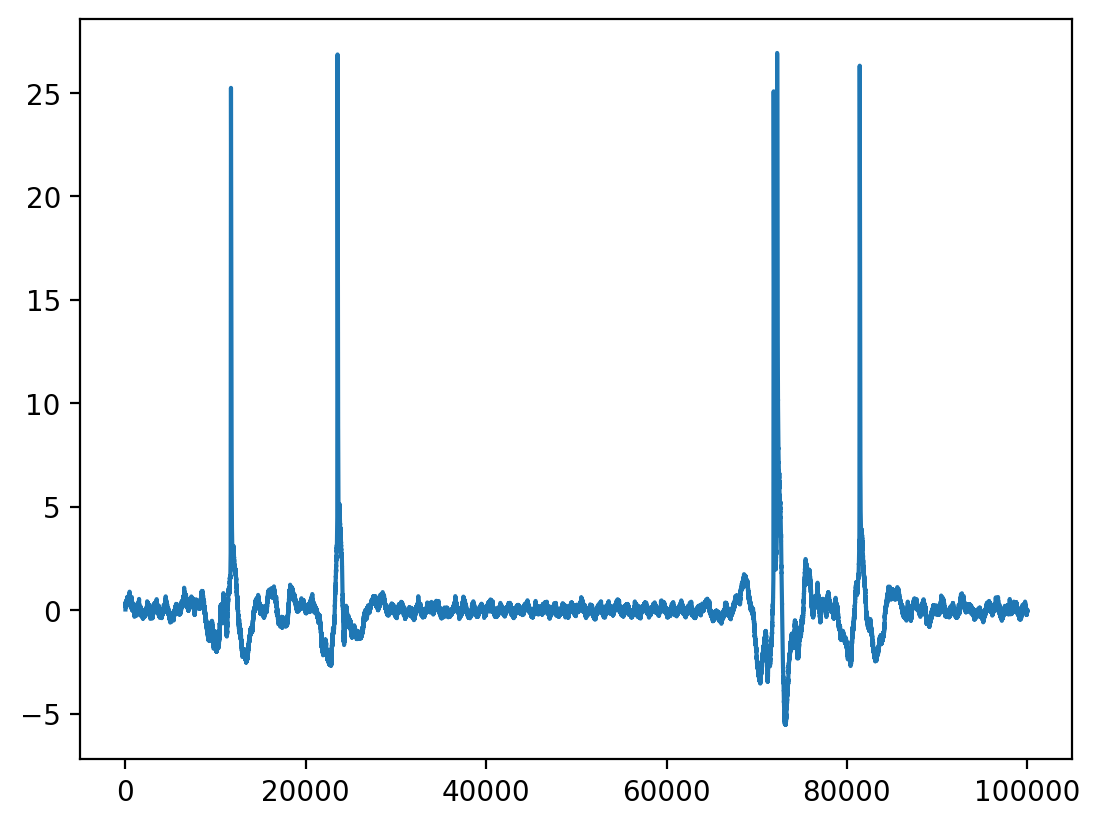

In [369]:
plt.plot(patch_filt[:100000] )

In [370]:



#threshold in mVs
sp = Spike(thresh_amp=10, window_length=(5., 5.), smooth_frac=.01)

In [371]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/626 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


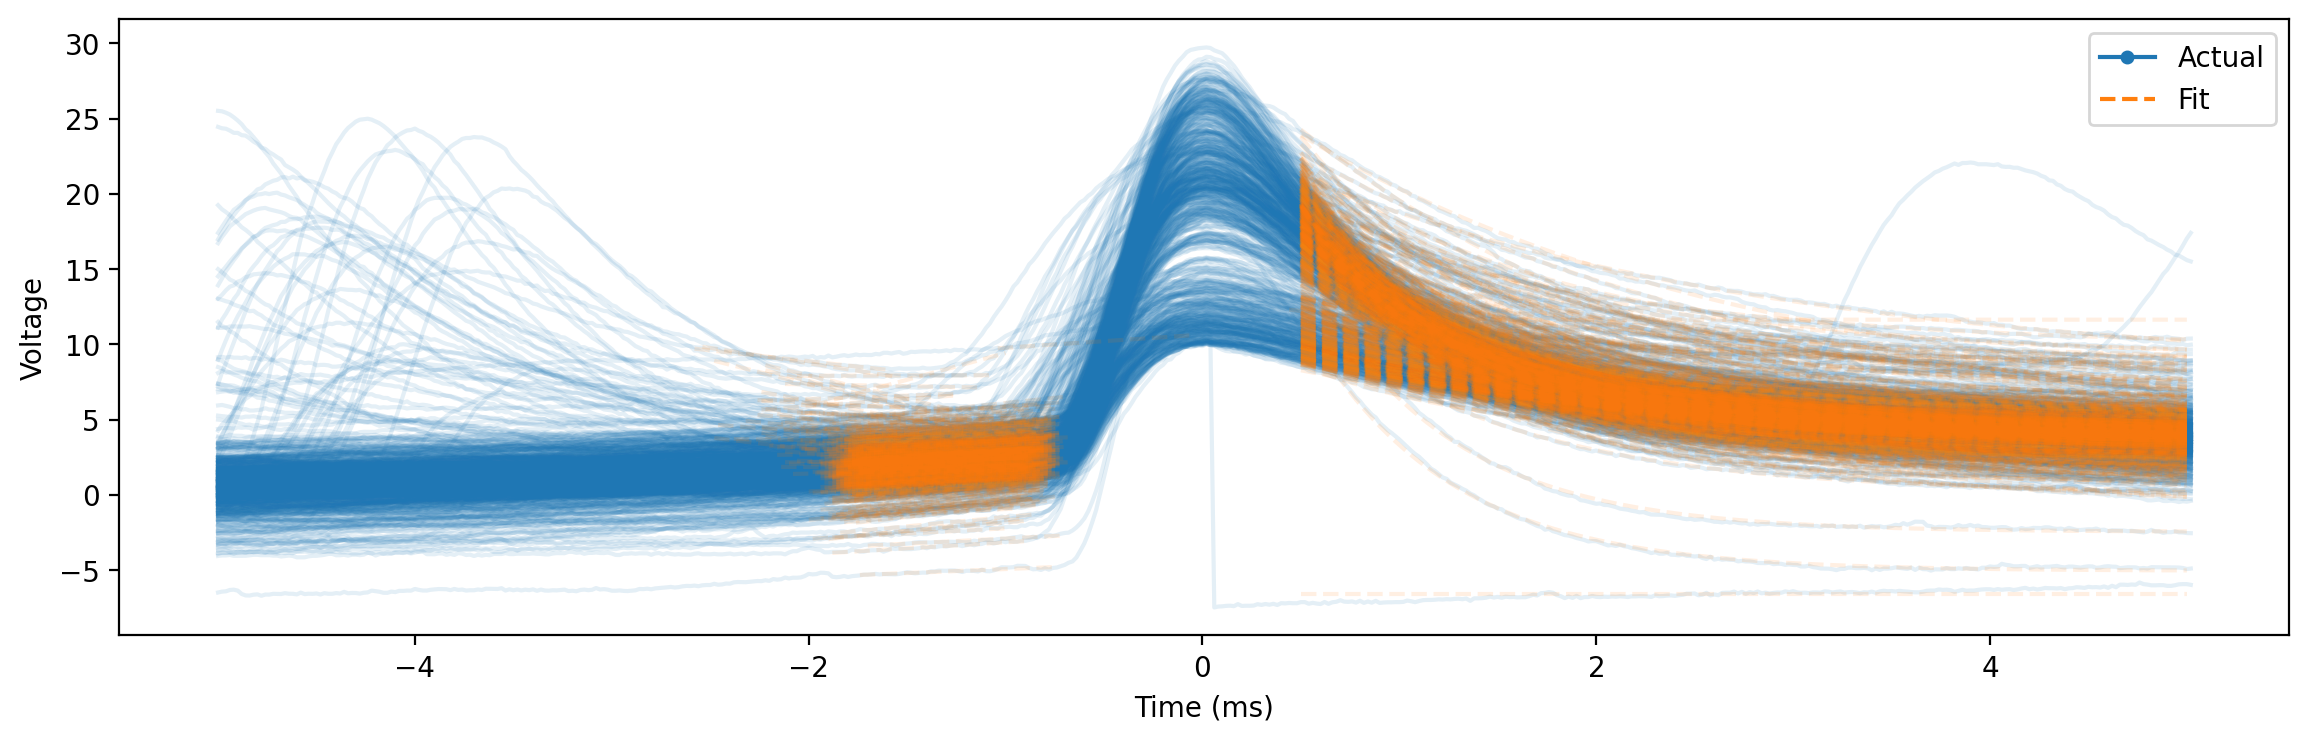

In [372]:
sp.plot()

### Filter spikes 

In [373]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [374]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [375]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,2.373367,11705,233.988239,0
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.988771,23523,470.235400,1
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,2.262434,72270,1444.709957,2
3,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,3.134033,81424,1627.702554,3
4,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,3.238045,149534,2989.252231,4
...,...,...,...,...,...,...,...,...,...,...,...,...
620,-0.265376,1.02,2.682118,10.791884,4.22,0.106704,0.380376,5.169002,3.897371,37325628,746156.170373,606
621,0.517355,0.70,3.353721,10.312721,1.78,0.165035,0.585853,3.846416,3.323366,37720584,754051.519285,607
622,-0.909968,1.02,4.727512,11.676022,3.28,0.151212,0.276106,4.721465,3.219649,37825912,756157.073600,608
624,-0.175349,1.08,4.097930,11.829634,3.78,0.121415,0.237549,4.137374,4.340976,38708847,773807.343230,609


### Get spike times


In [376]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 4: Get avg waveform and for every spike, calculate error (aligned to peak)

In [377]:
#get root mean squared errors
errs = spike_waveform_errors(sp, metric="rmse") 


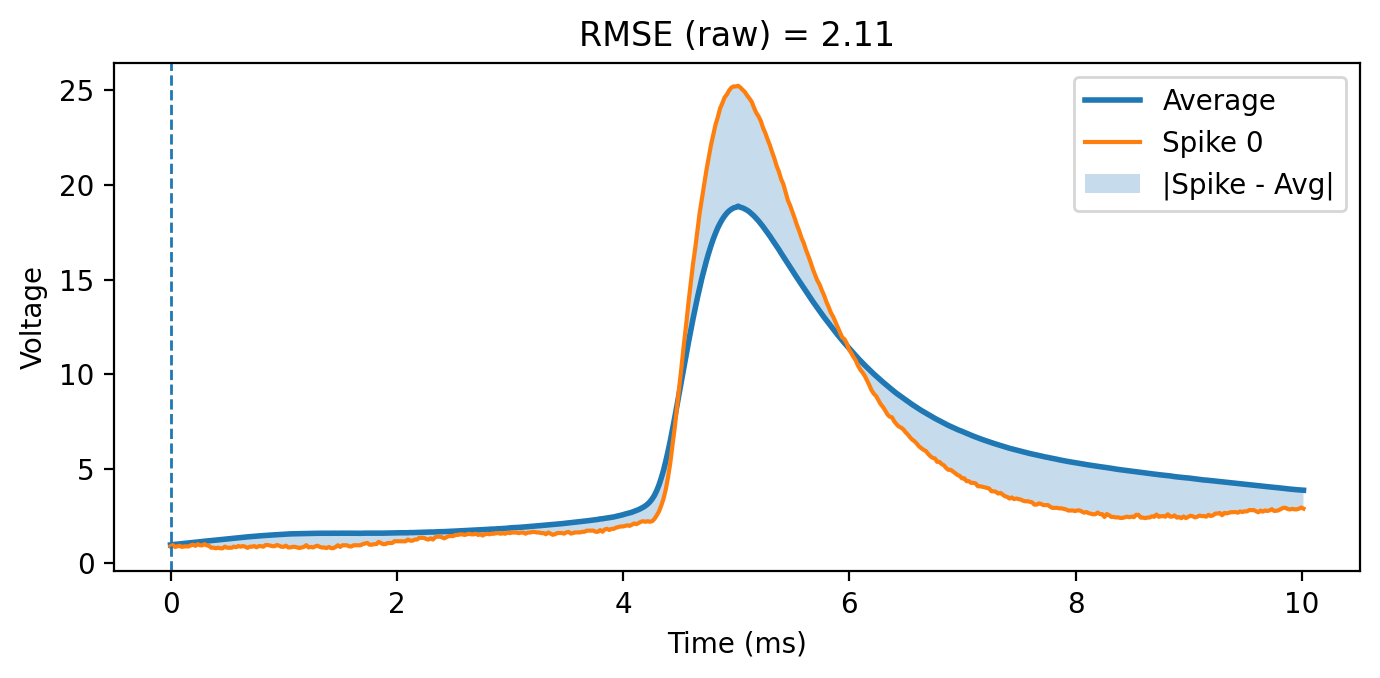

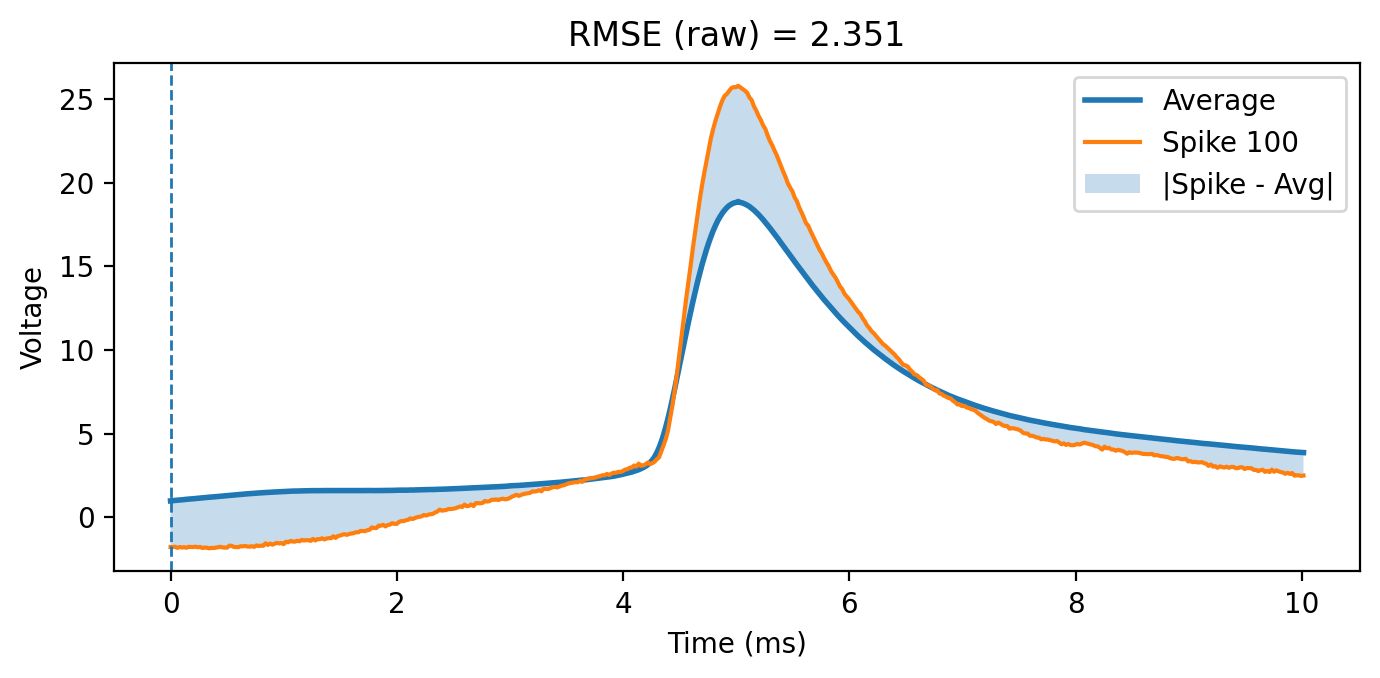

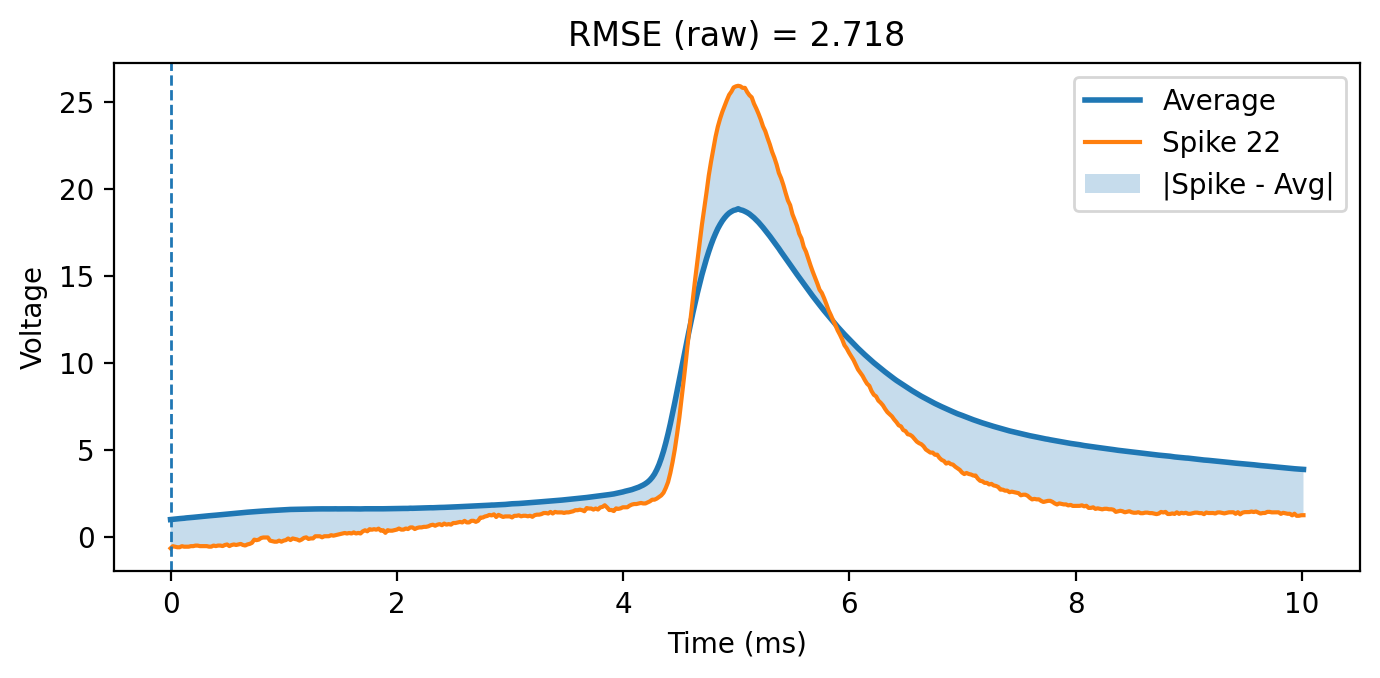

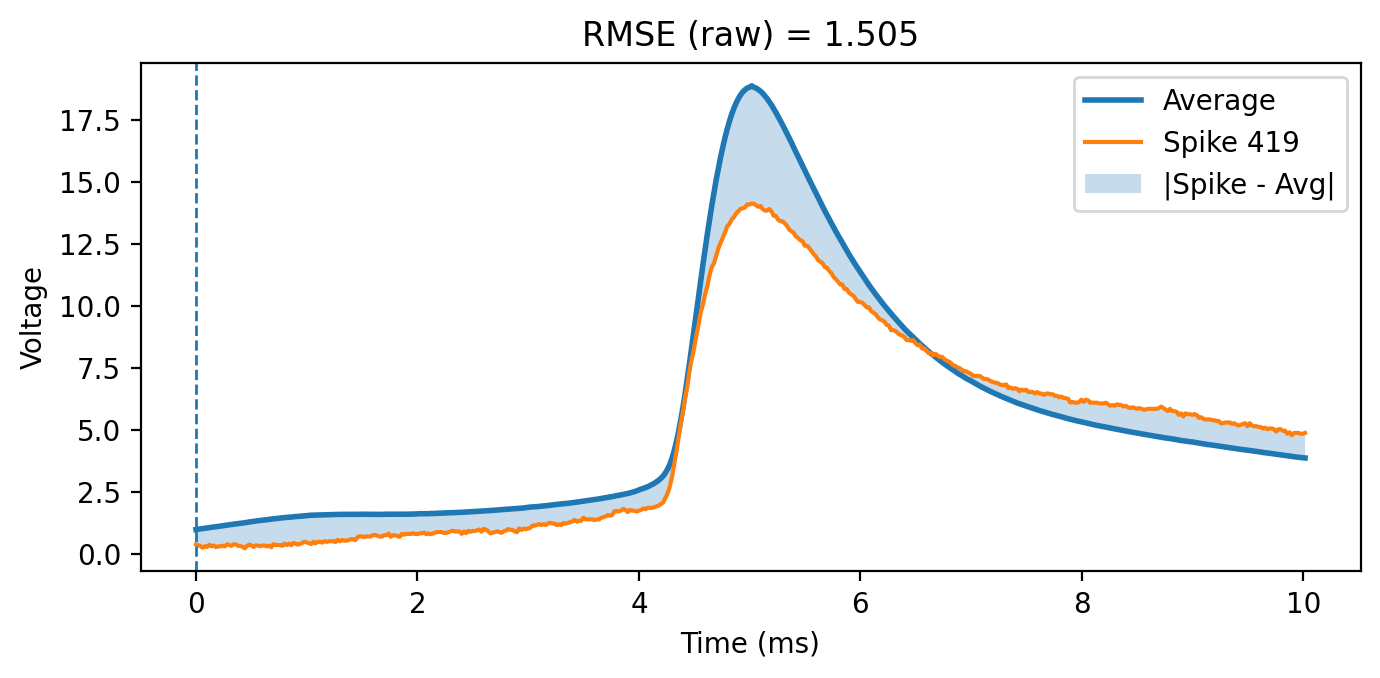

In [378]:
#Examples
e = visualize_spike_error(sp, spike_idx=0, metric="rmse", show_residual=True)
e = visualize_spike_error(sp, spike_idx=100, metric="rmse", show_residual=True)
e = visualize_spike_error(sp, spike_idx=22, metric="rmse", show_residual=True)
e = visualize_spike_error(sp, spike_idx=419, metric="rmse", show_residual=True)


## STEP 4: Map spikes to windows and create df with spike error, LFP AUC and aperiodic exponent

In [379]:
#generate df with spike waveform errors, lfp window auc and aperiodic exponent
spike_lfp_df = make_spike_waveform_error_and_auc_df(errs, df_features, window_times_mt, lfp_fs, specp_auc_df)


In [380]:
spike_lfp_df

,spk_id,spk_times_ms,wf_error,win_idx,gamma_auc,aperiodic_exponent
0,0,233.988239,2.110317,58.0,17.711053,2.012163
1,1,470.235400,2.130798,117.0,24.541423,2.147111
2,2,1444.709957,3.184825,361.0,21.649121,1.795145
3,3,1627.702554,2.002792,406.0,16.588852,1.084621
4,4,2989.252231,2.188142,747.0,13.902679,1.797996
...,...,...,...,...,...,...
606,606,746156.170373,3.085849,186539.0,14.775479,1.440865
607,607,754051.519285,2.752751,188512.0,25.719986,2.001895
608,608,756157.073600,3.498201,189039.0,25.509550,1.057939
609,609,773807.343230,3.569605,193451.0,17.868972,1.730531


Text(0, 0.5, 'gamma auc')

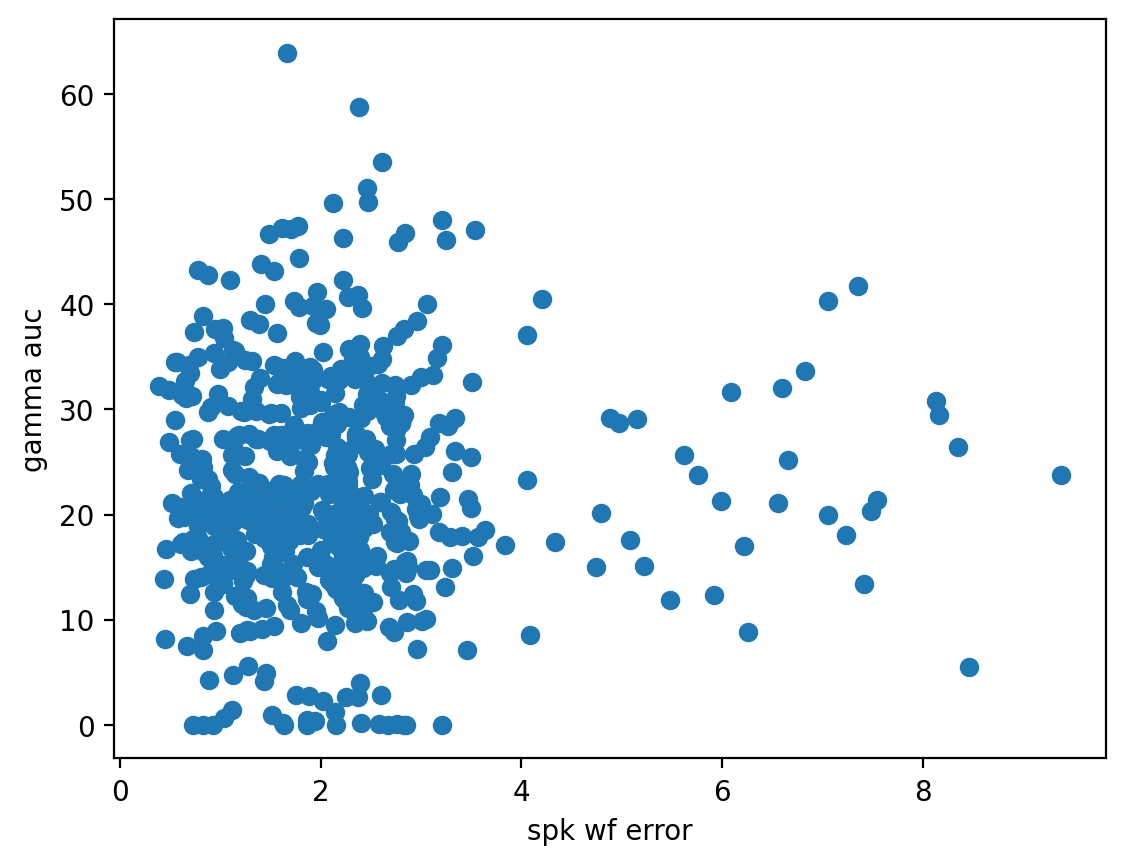

In [381]:
plt.scatter(spike_lfp_df['wf_error'], spike_lfp_df['gamma_auc'])
plt.xlabel("spk wf error")
plt.ylabel("gamma auc")

Text(0, 0.5, 'aperiodic exponent')

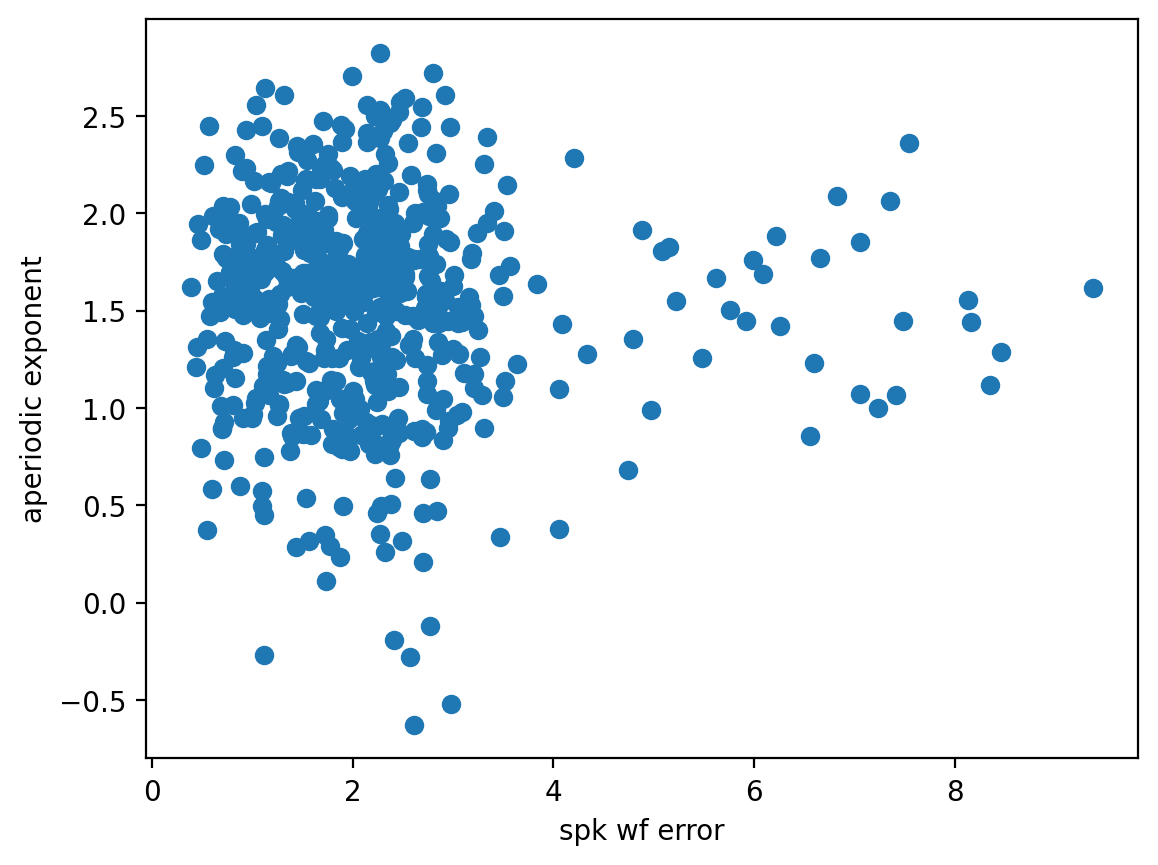

In [382]:
plt.scatter(spike_lfp_df['wf_error'], spike_lfp_df['aperiodic_exponent'])
plt.xlabel("spk wf error")
plt.ylabel("aperiodic exponent")

## STEP 5: Build regression to predict per-spike error as a combination of the gamma AUC and the aperiodic exponent - RIP - didn't work

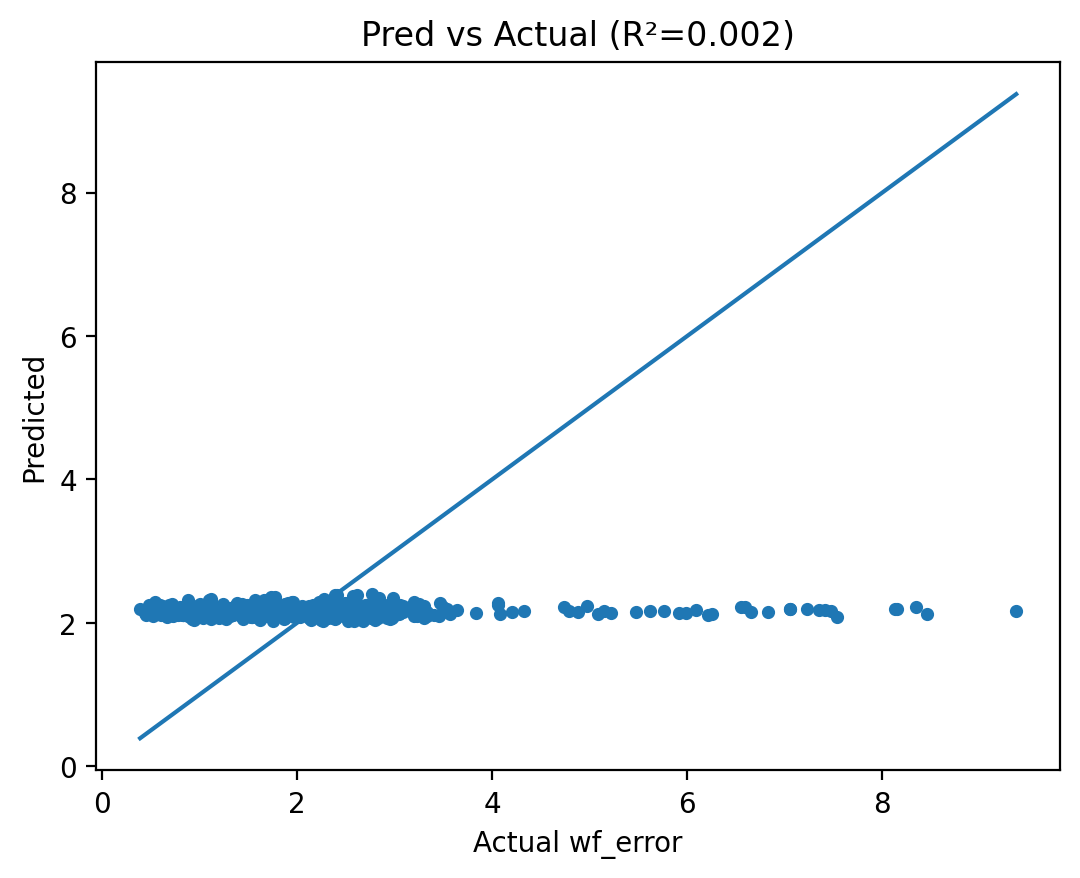

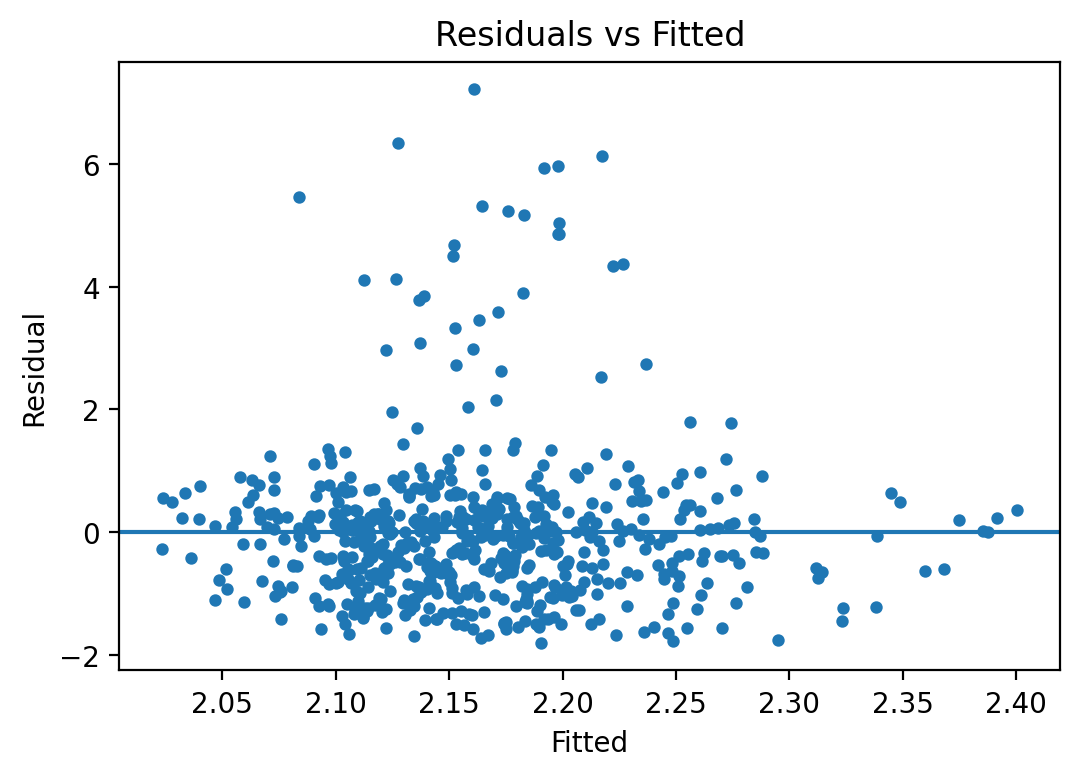

                        coef        se          z     P>|z|     ci_lo  \
const               2.162008  0.051770  41.761436  0.000000  2.060540   
gamma_auc           0.036250  0.048301   0.750498  0.452955 -0.058418   
aperiodic_exponent -0.049476  0.042881  -1.153785  0.248588 -0.133522   

                       ci_hi  
const               2.263476  
gamma_auc           0.130918  
aperiodic_exponent  0.034570  


In [383]:
res = fit_linear_regression(
    spike_lfp_df,
    y_col="wf_error",
    x_cols=["gamma_auc", "aperiodic_exponent"],
    standardize=True,
    interactions=False,
    robust_se=True,
    do_cv=True,
    cv_splits=5,
    plot=True,
)
print(res["coefs"])


### STEP 6: See if AUC and aperiodic exponent correlate with spike params 

In [384]:
#create combined df with new LFP features and spike params 

#make sure the left DF has a 'spk_id' column to join on
spike_lfp_df_ = spike_lfp_df.copy()
if "spk_id" not in spike_lfp_df_.columns and "pk_id" in spike_lfp_df_.columns:
    spike_lfp_df_ = spike_lfp_df_.rename(columns={"pk_id": "spk_id"})

# select the feature columns you want from df_features (index by spk_id for a clean join)
feat_cols = [
    "ramp_amp",
    "inflection_time",
    "inflection_amp",
    "peak_amp",
    "peak_width",
    "peak_sharpness",
    "exp_lambda",
    "exp_const",
    "log_isi",
]
feat = df_features.set_index("spk_id")[feat_cols]

# left join by spk_id
spike_lfp_with_feats = spike_lfp_df_.join(feat, on="spk_id", how="left")




In [385]:
spike_lfp_with_feats

,spk_id,spk_times_ms,wf_error,win_idx,gamma_auc,aperiodic_exponent,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi
0,0,233.988239,2.110317,58.0,17.711053,2.012163,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,2.373367
1,1,470.235400,2.130798,117.0,24.541423,2.147111,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.988771
2,2,1444.709957,3.184825,361.0,21.649121,1.795145,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,2.262434
3,3,1627.702554,2.002792,406.0,16.588852,1.084621,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,3.134033
4,4,2989.252231,2.188142,747.0,13.902679,1.797996,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,3.238045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,606,746156.170373,3.085849,186539.0,14.775479,1.440865,-0.265376,1.02,2.682118,10.791884,4.22,0.106704,0.380376,5.169002,3.897371
607,607,754051.519285,2.752751,188512.0,25.719986,2.001895,0.517355,0.70,3.353721,10.312721,1.78,0.165035,0.585853,3.846416,3.323366
608,608,756157.073600,3.498201,189039.0,25.509550,1.057939,-0.909968,1.02,4.727512,11.676022,3.28,0.151212,0.276106,4.721465,3.219649
609,609,773807.343230,3.569605,193451.0,17.868972,1.730531,-0.175349,1.08,4.097930,11.829634,3.78,0.121415,0.237549,4.137374,4.340976


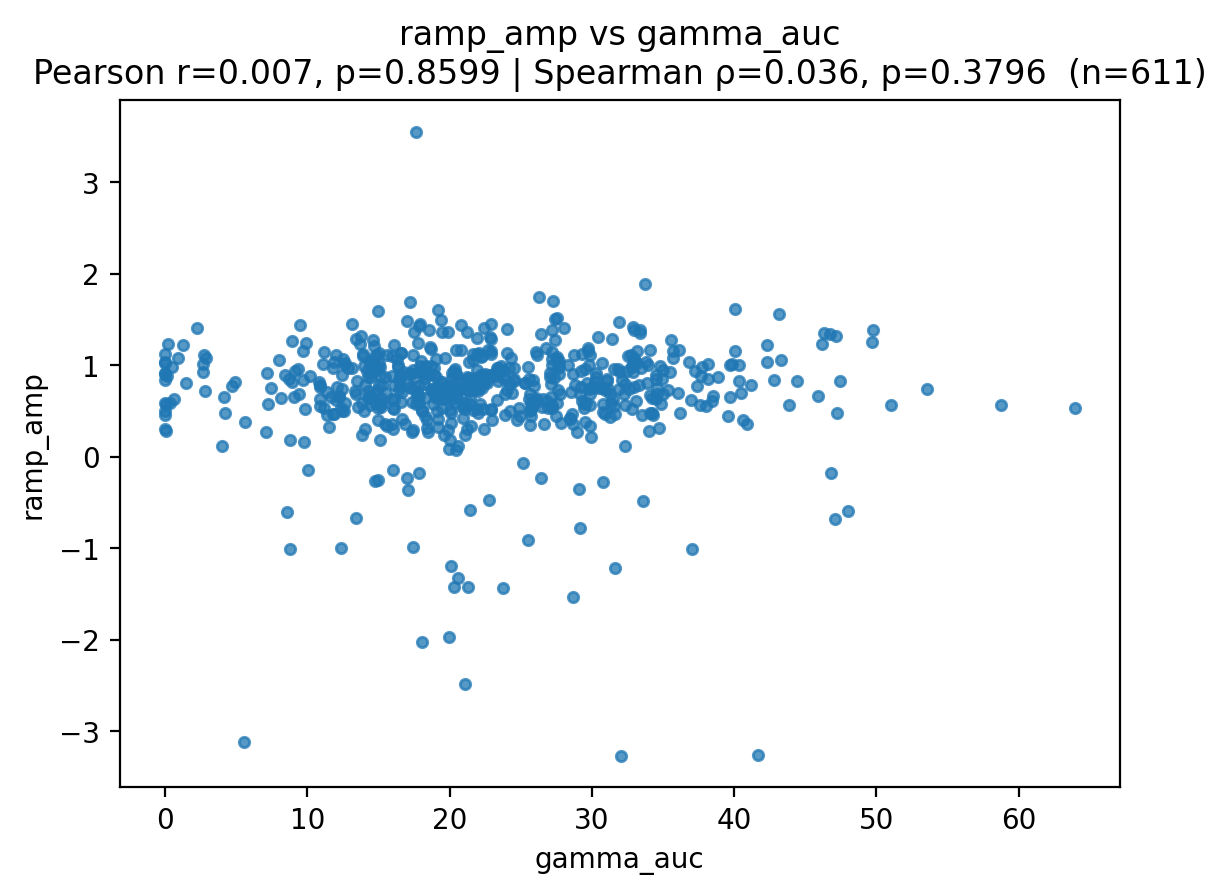

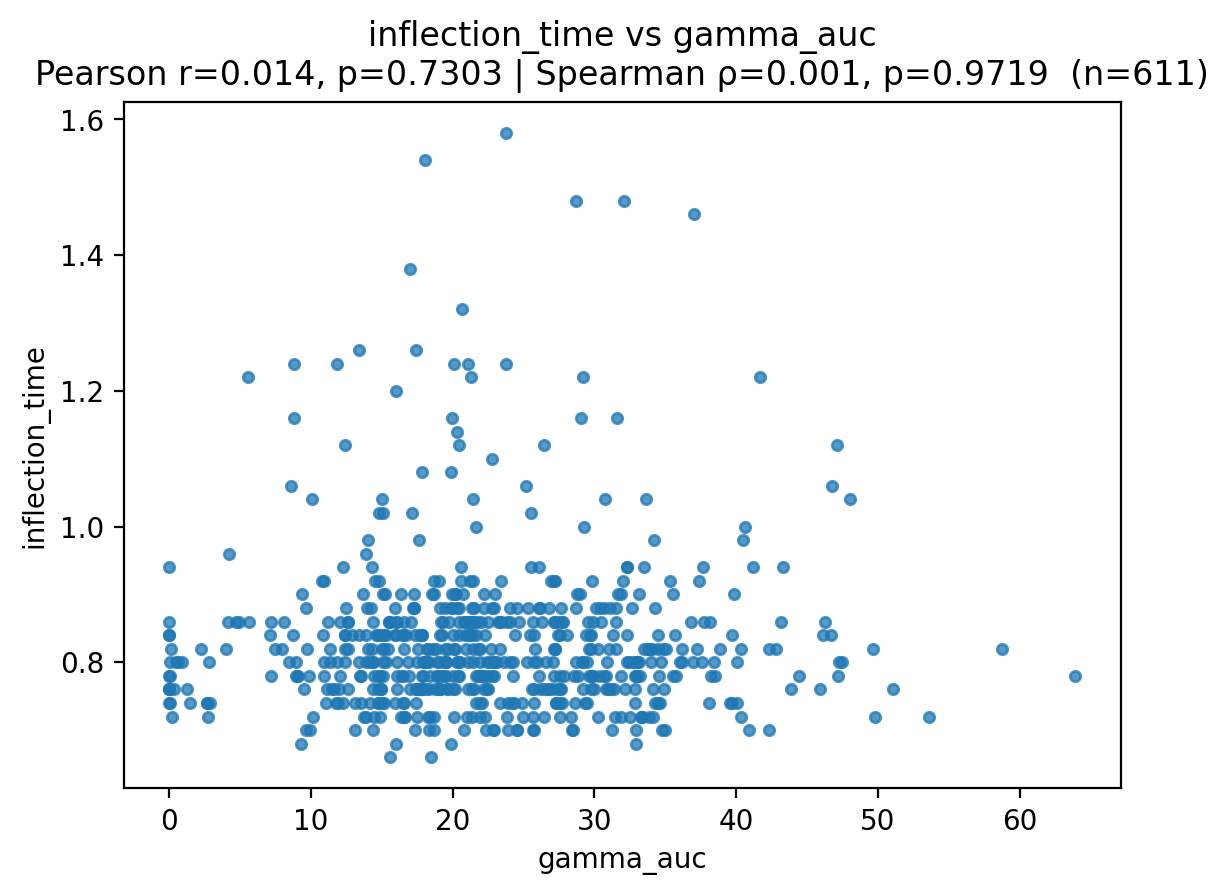

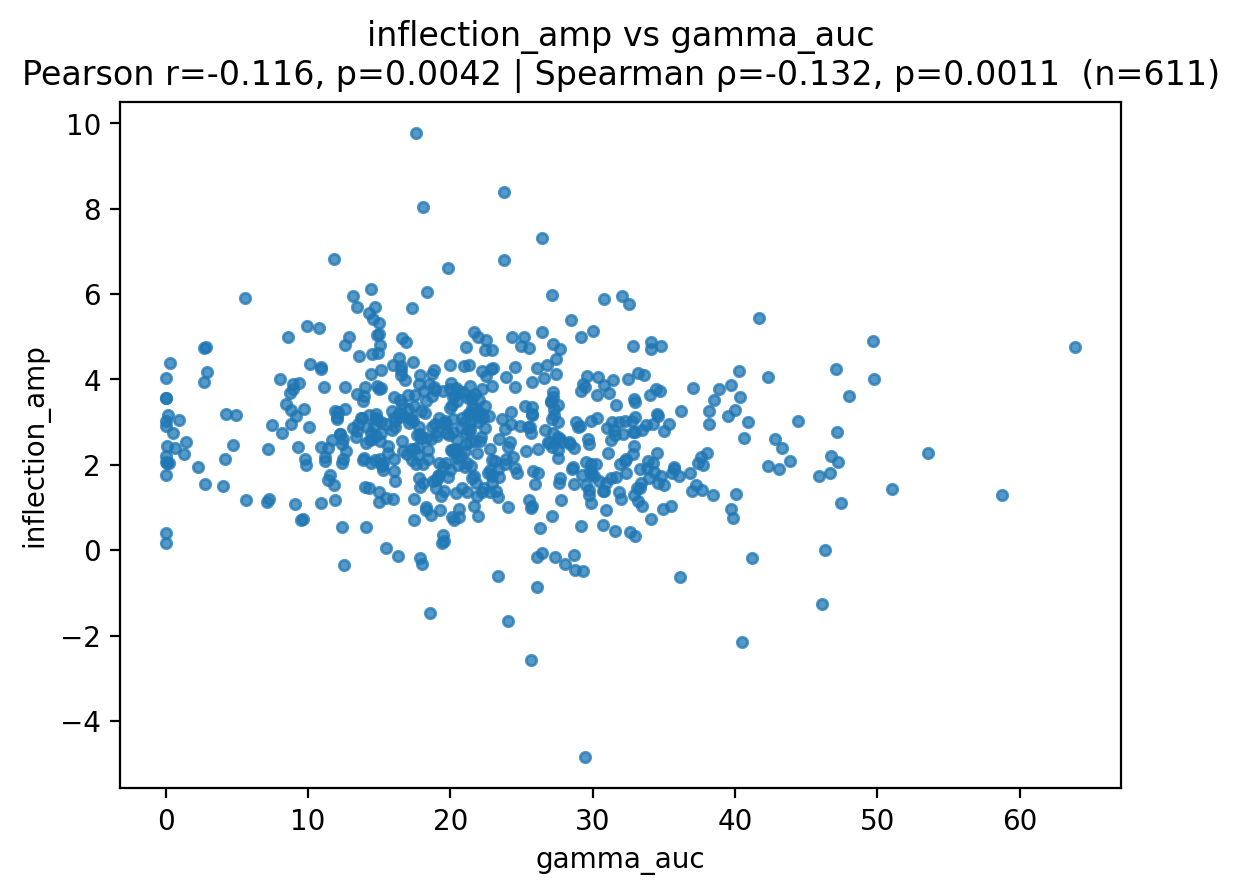

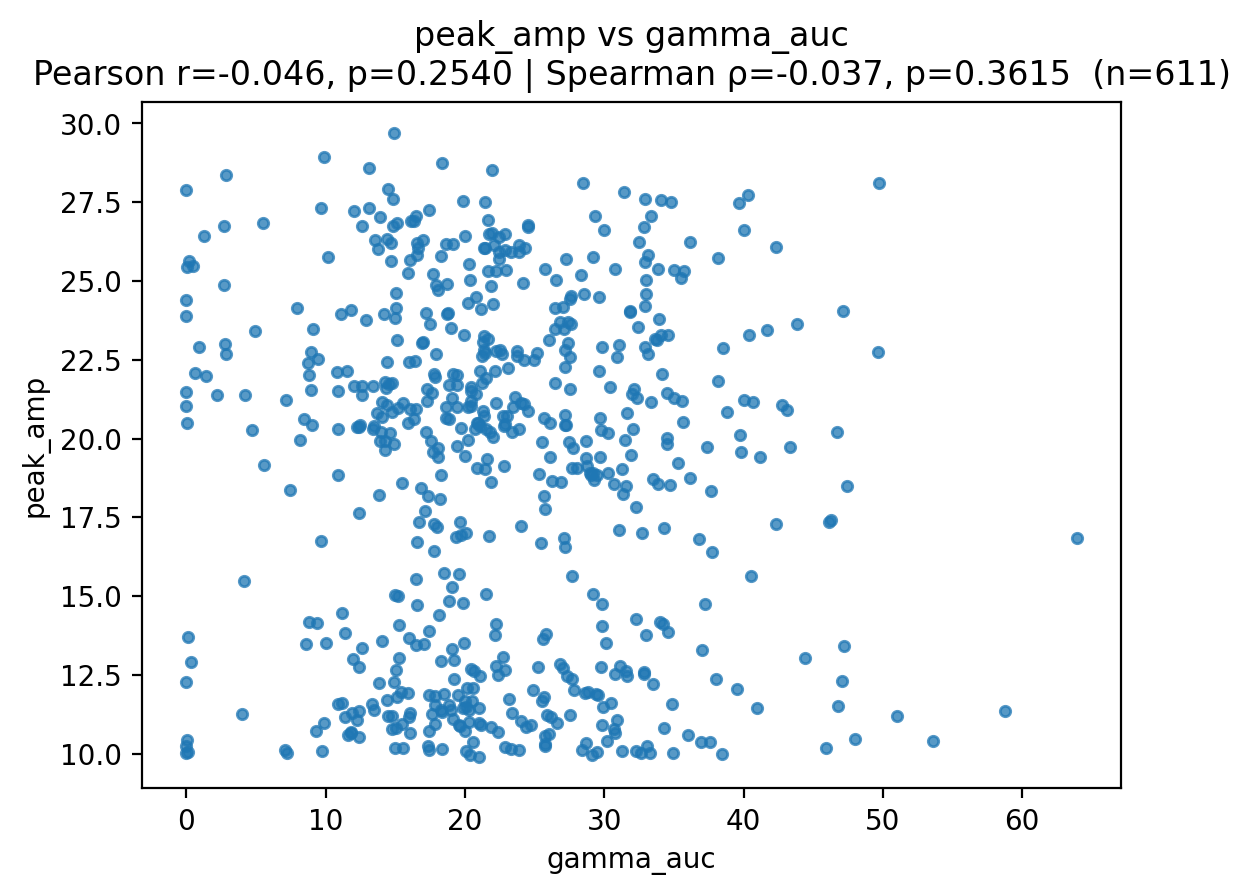

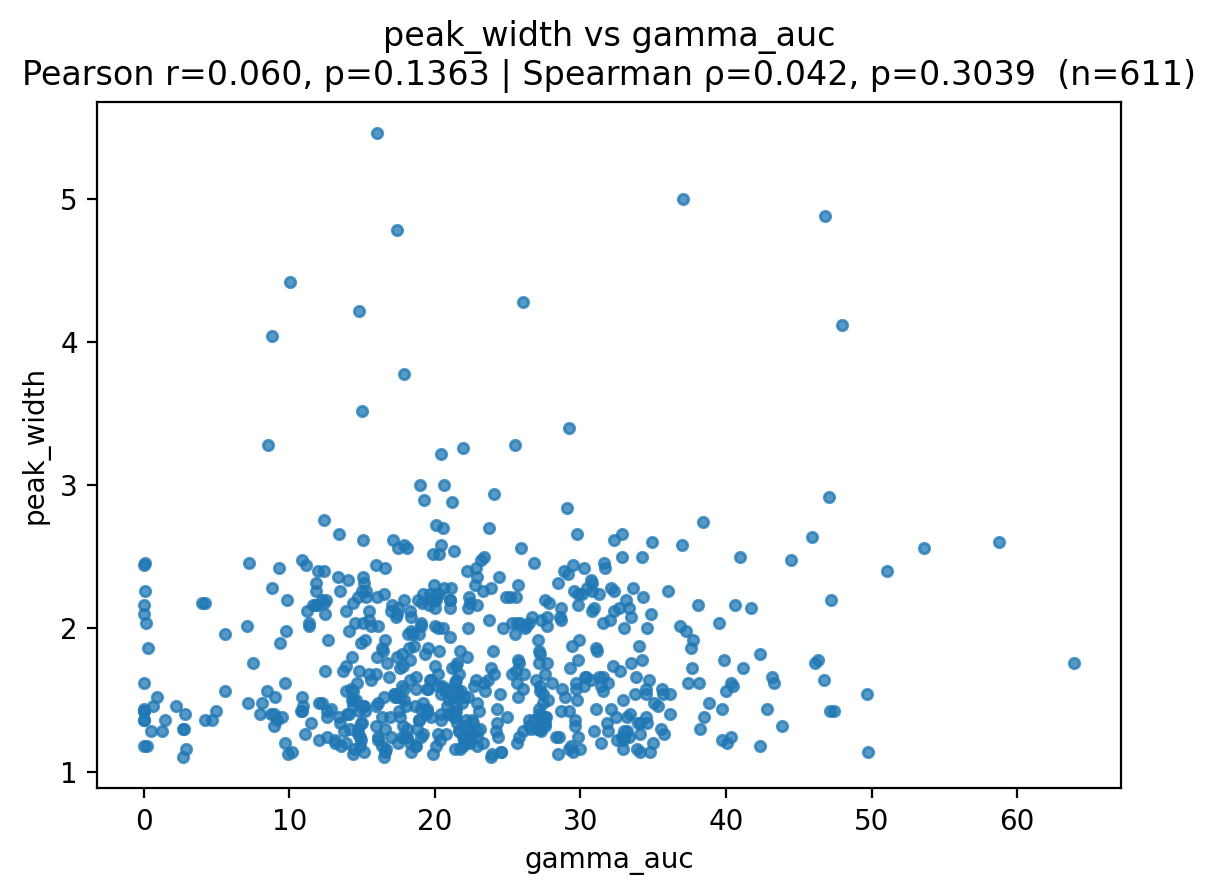

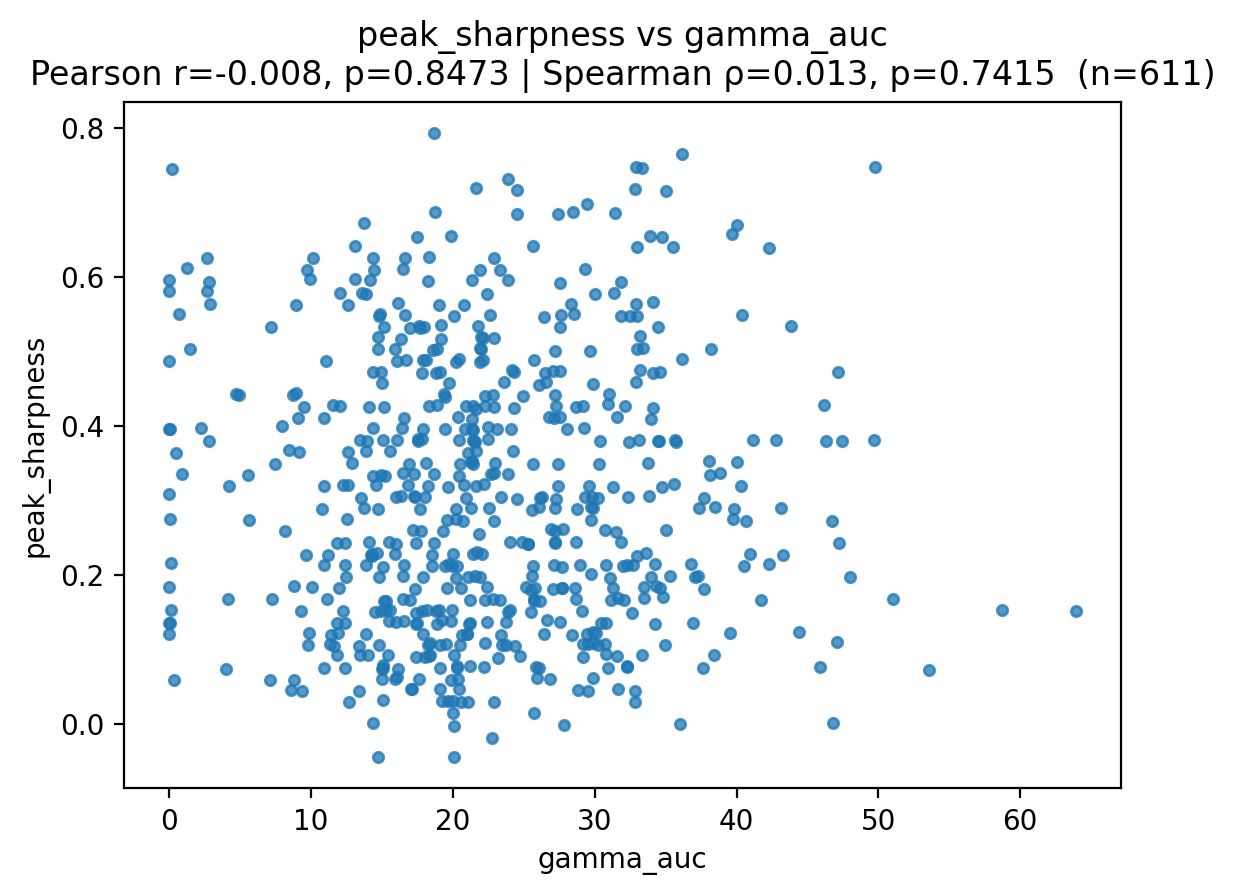

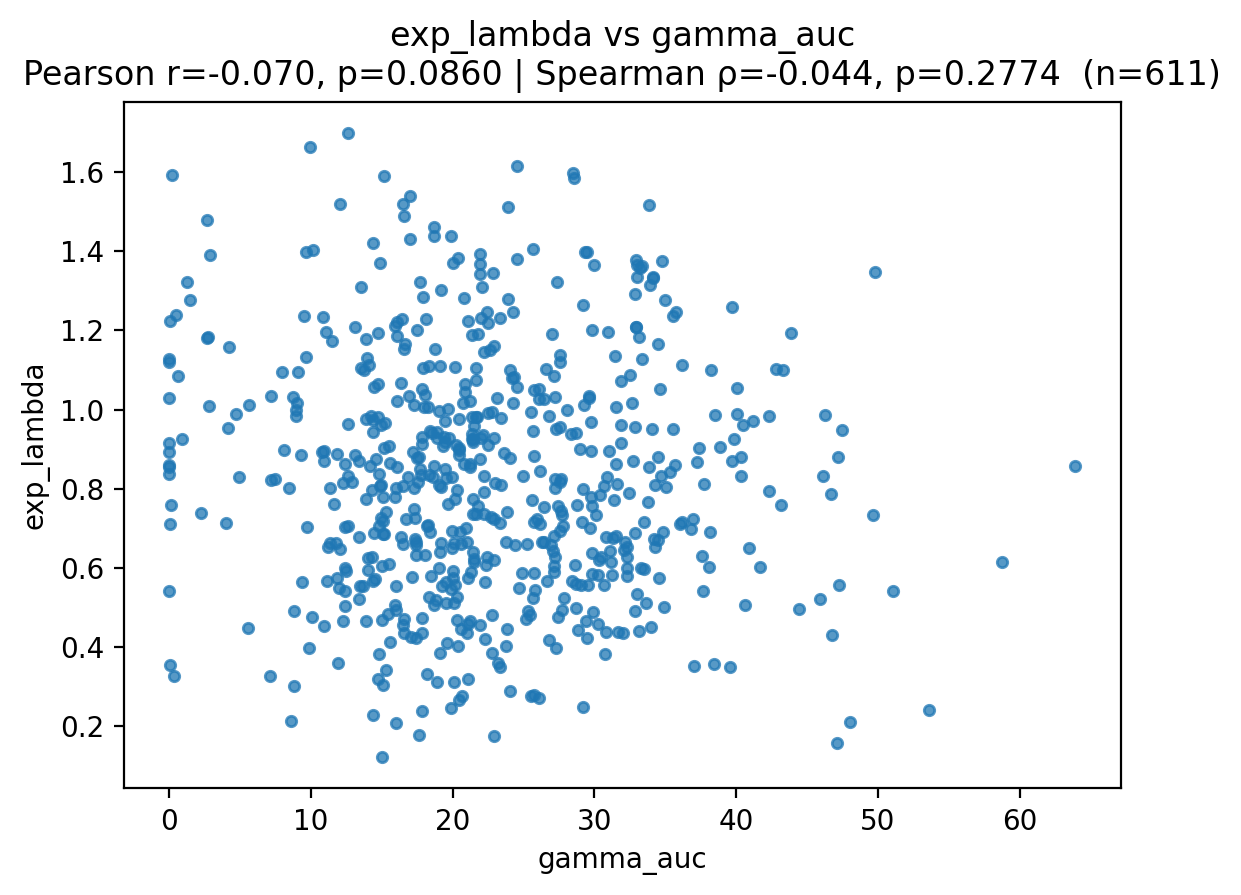

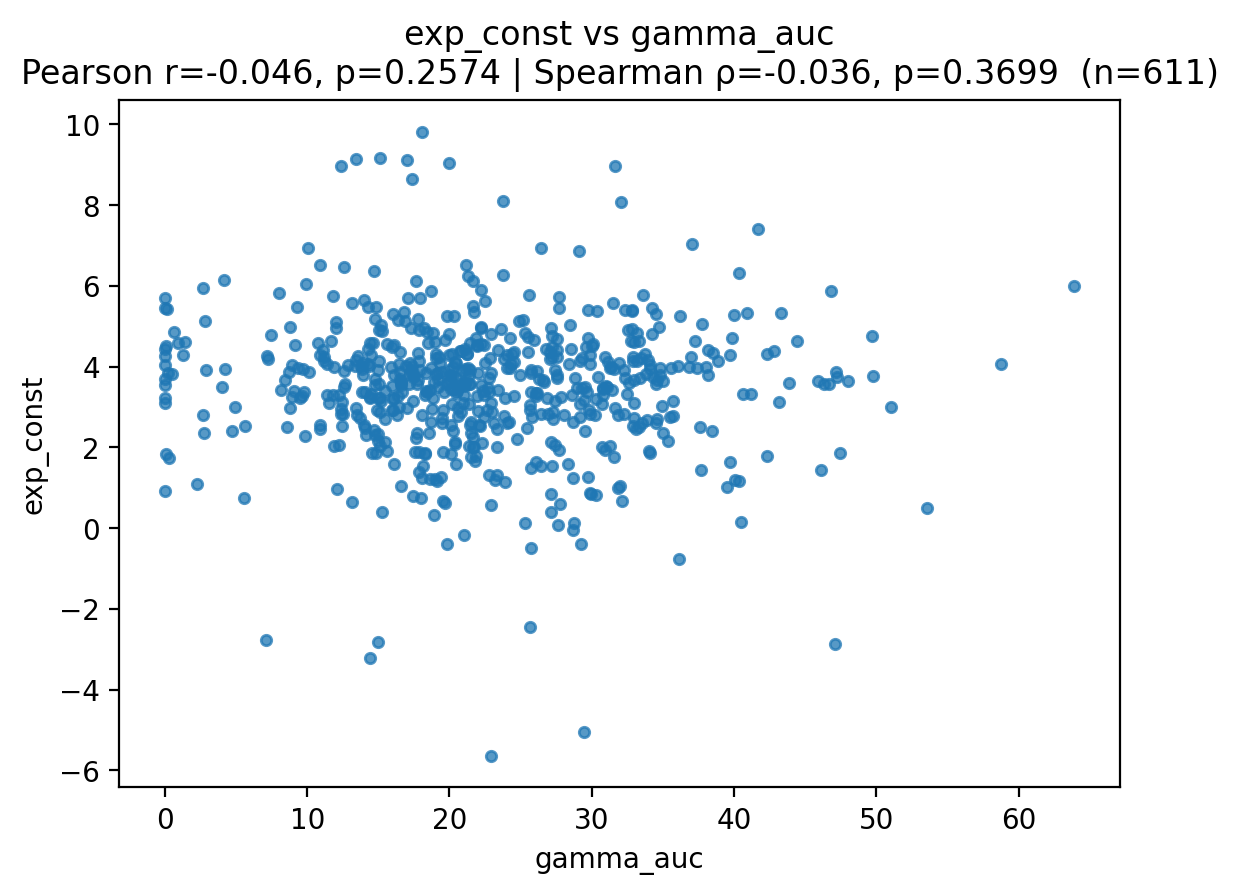

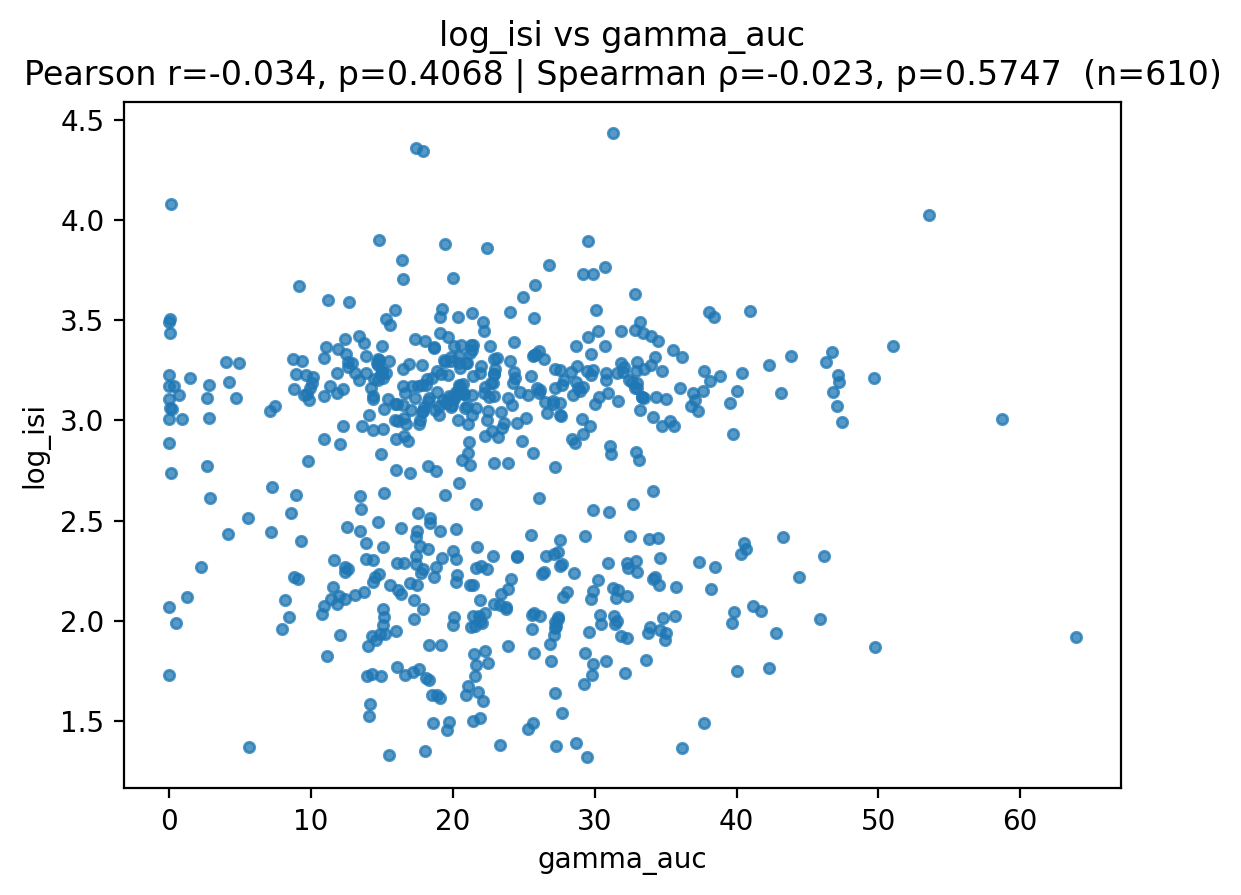

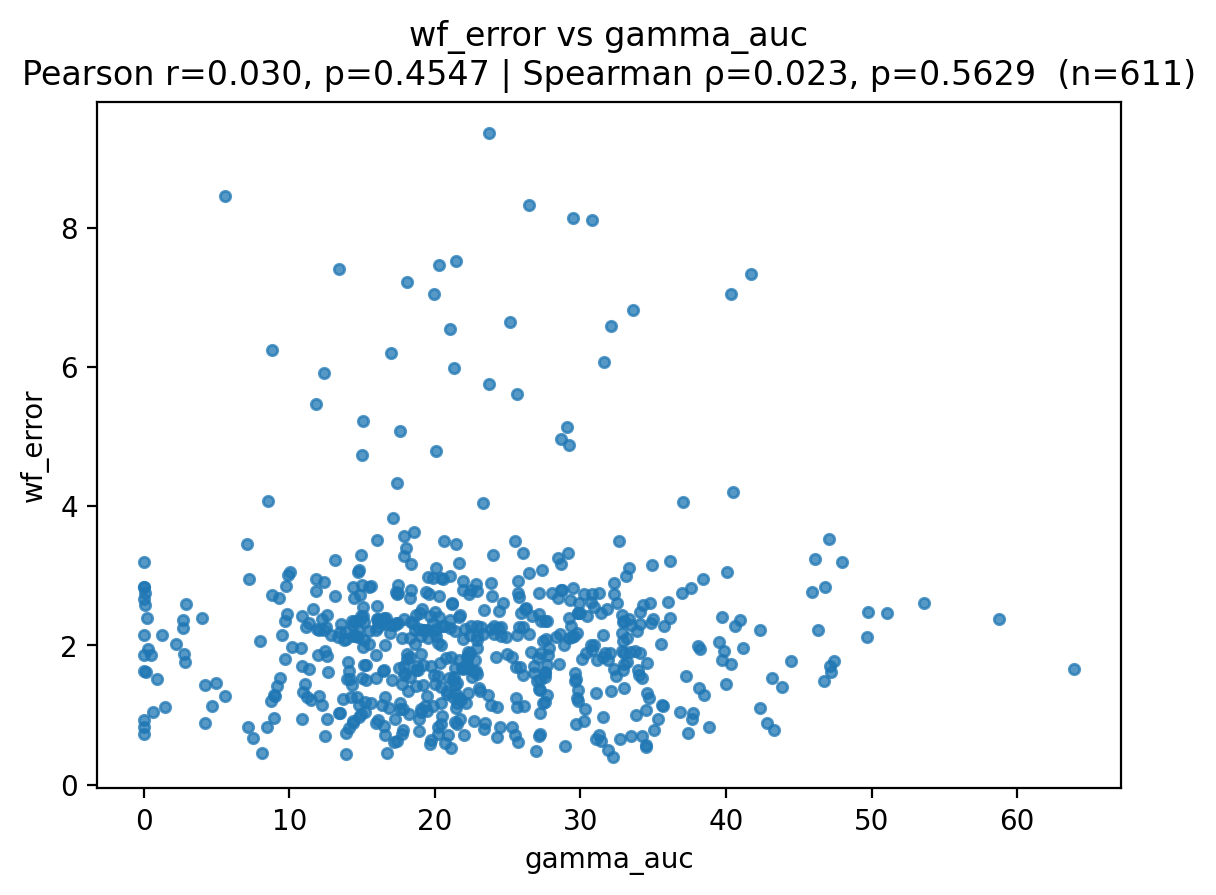

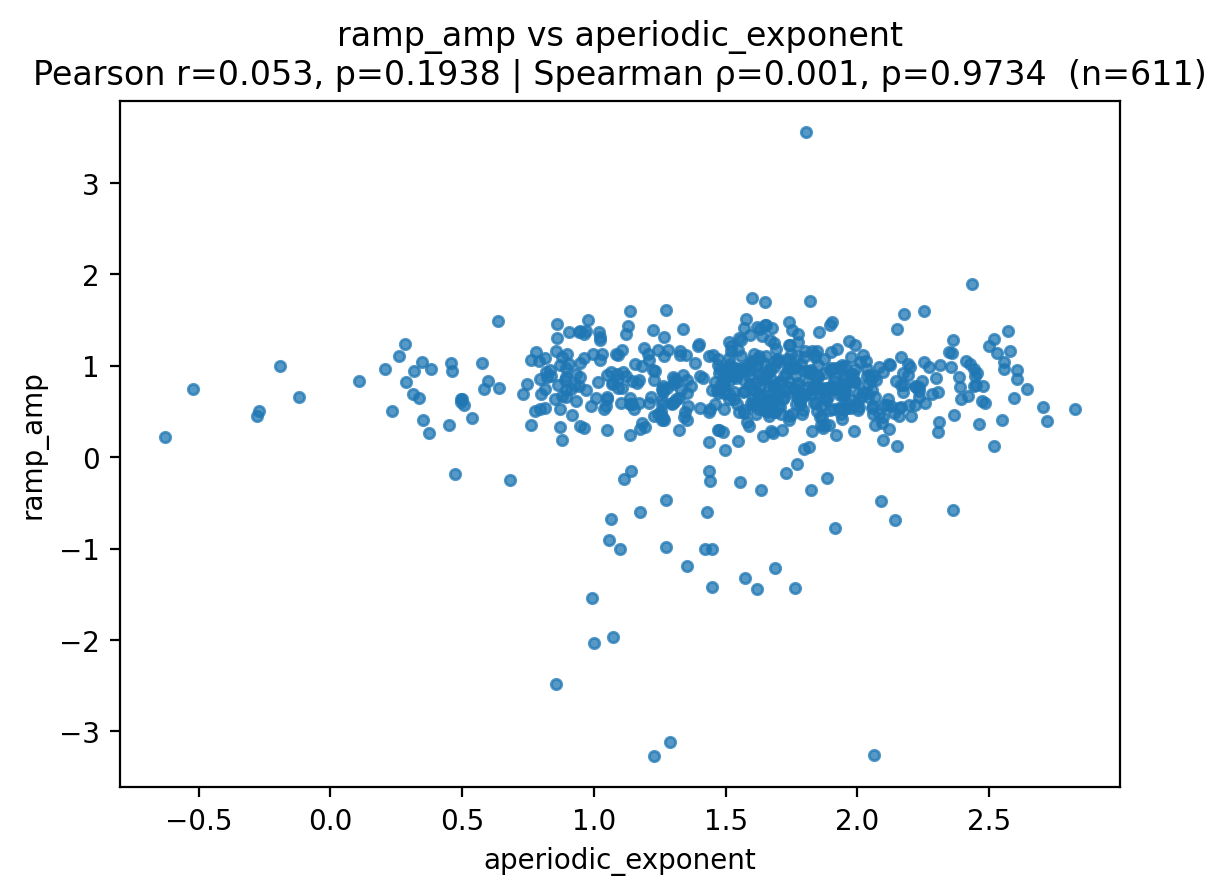

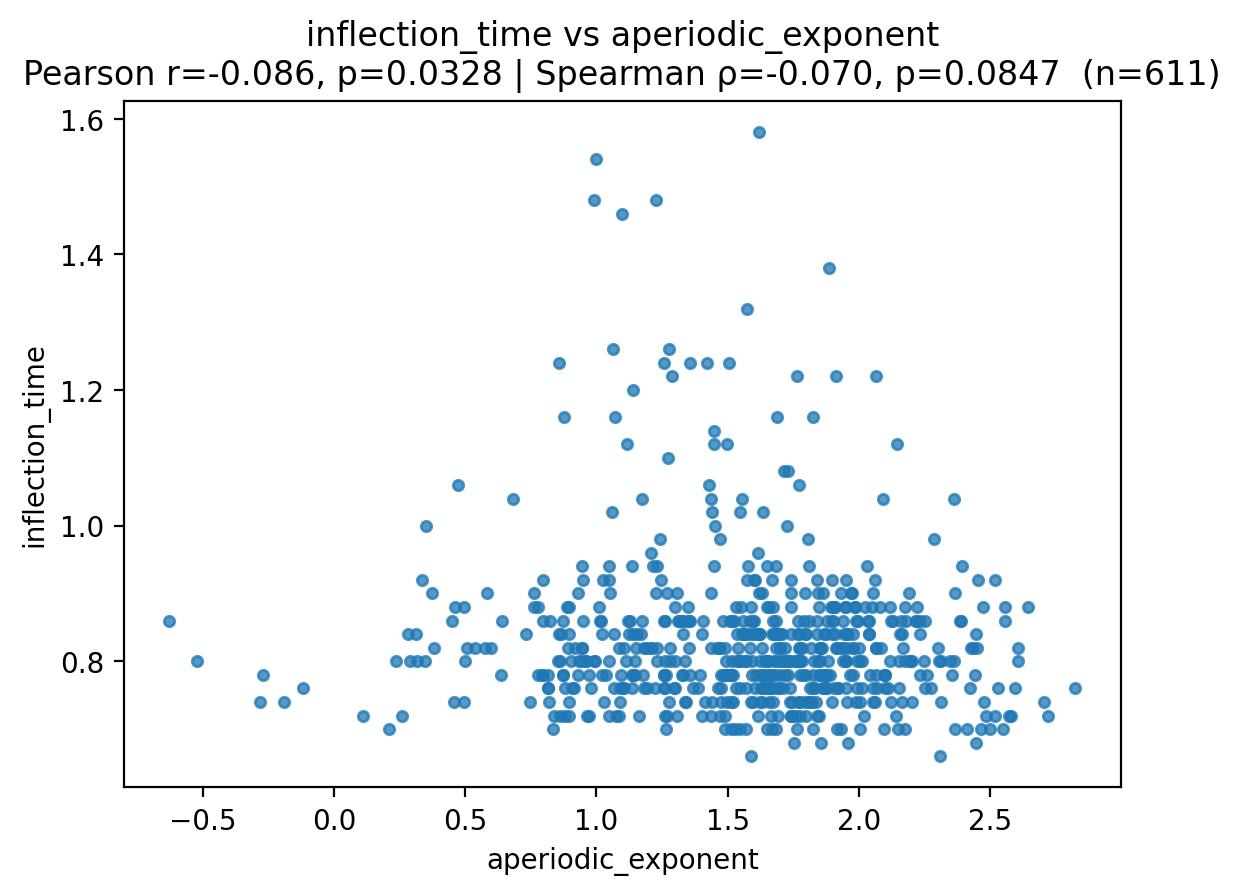

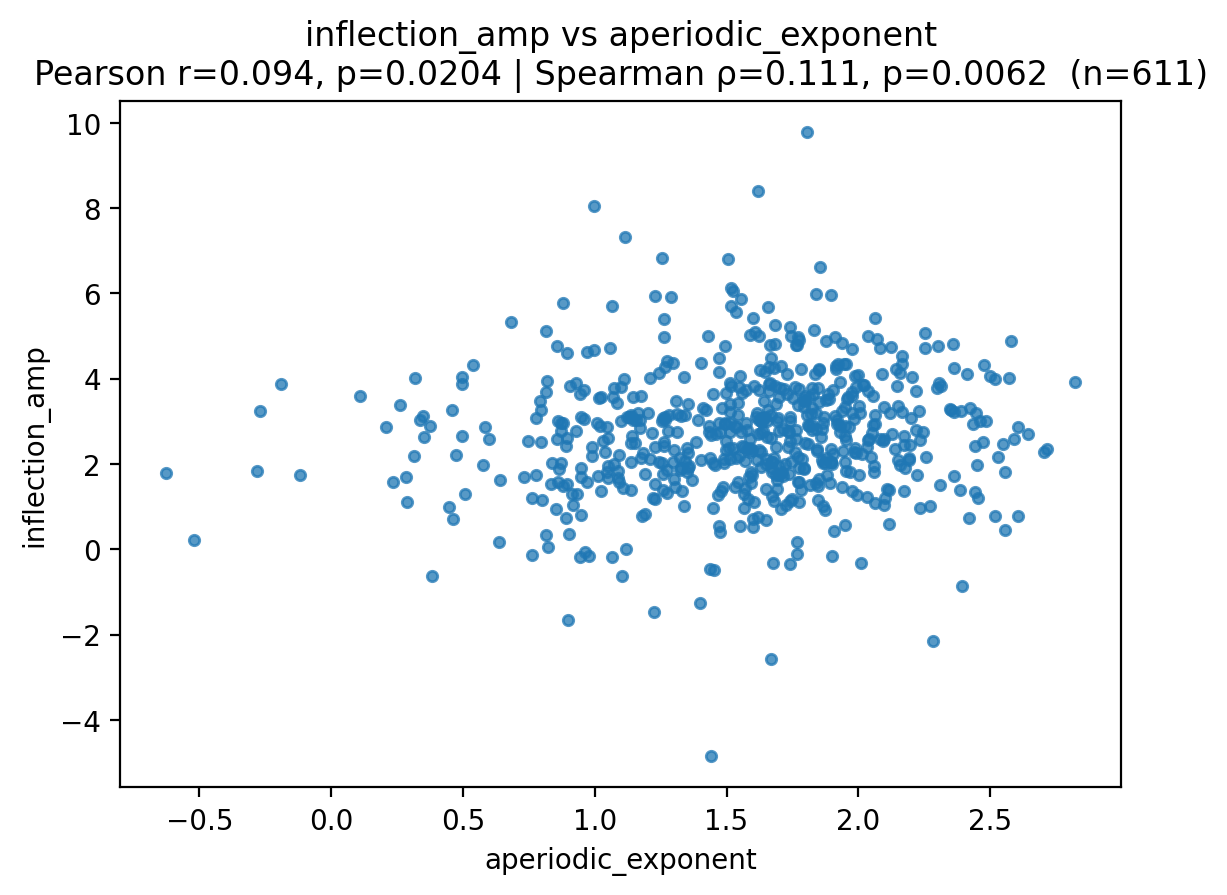

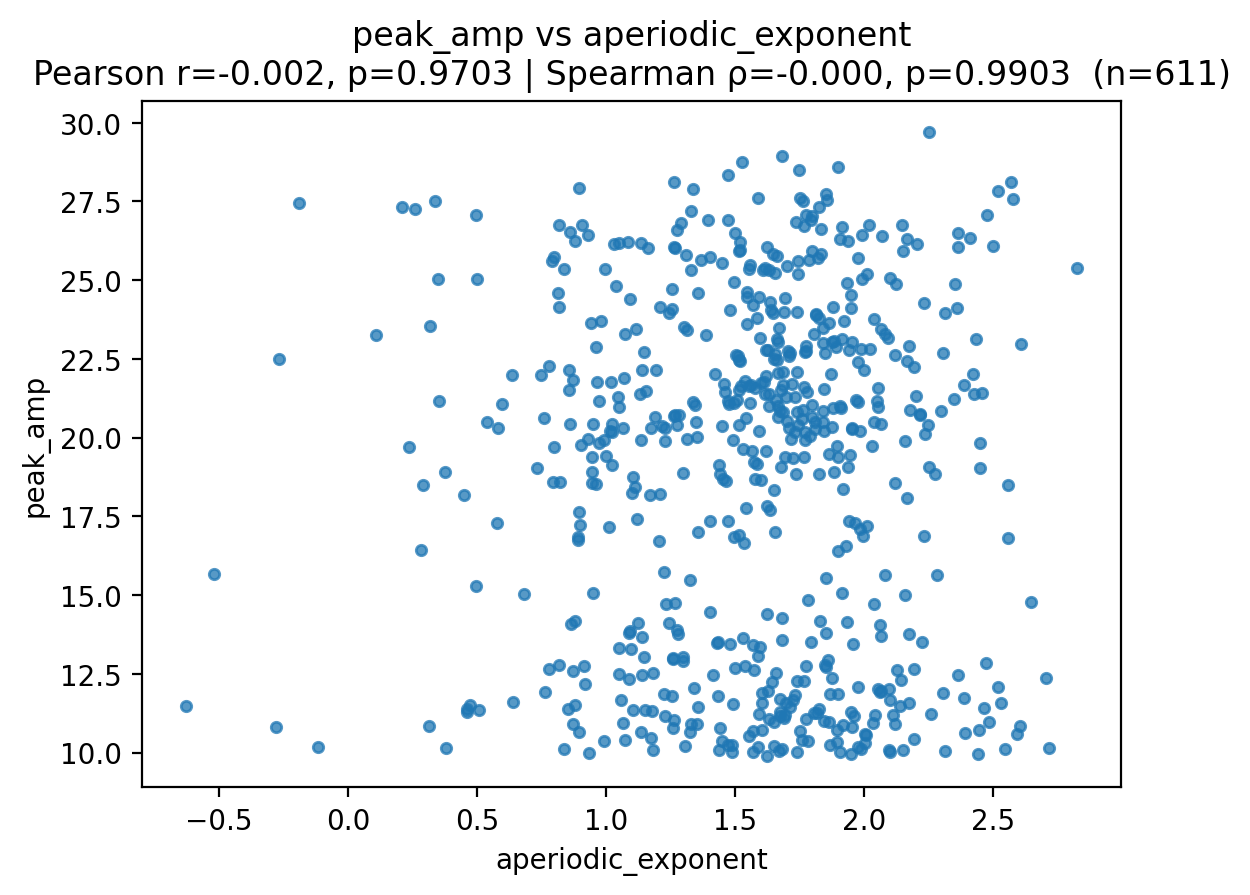

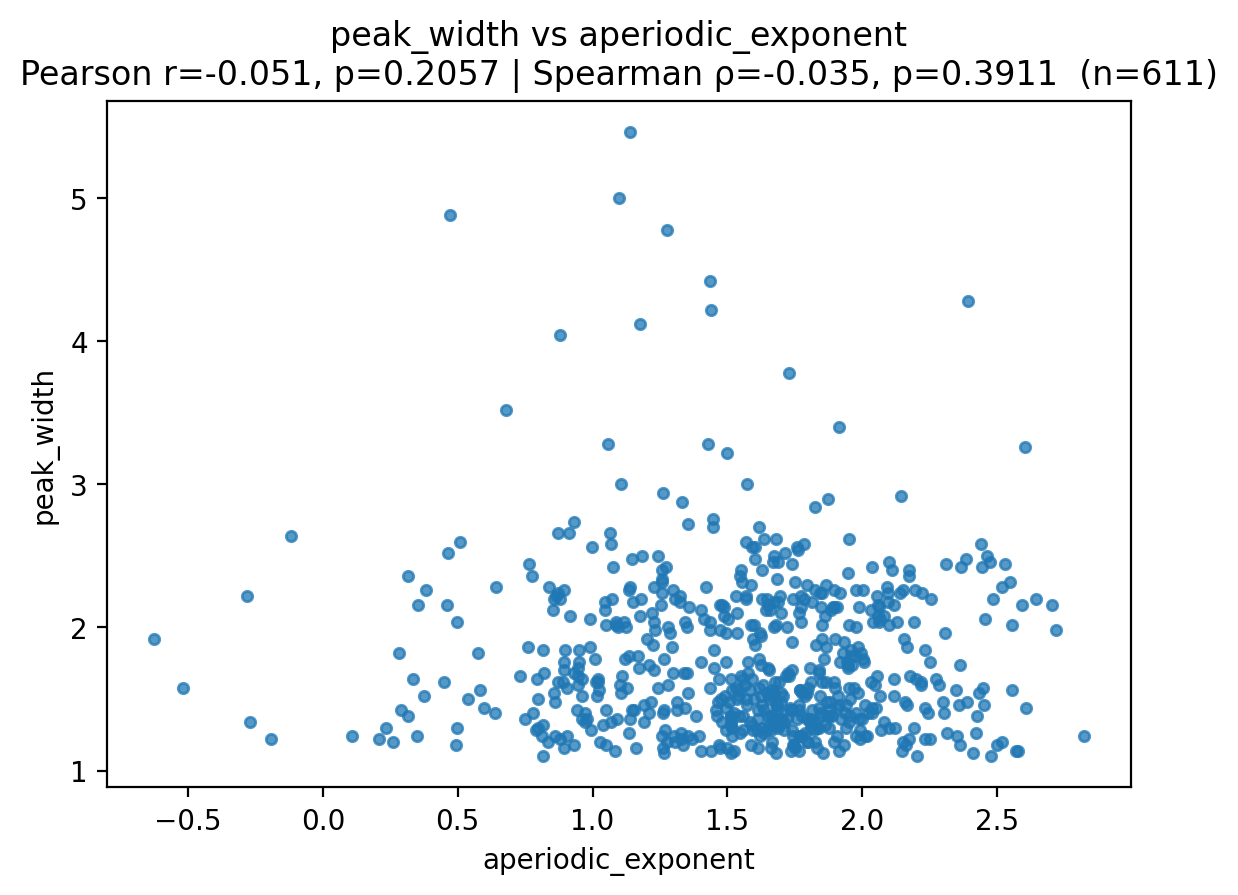

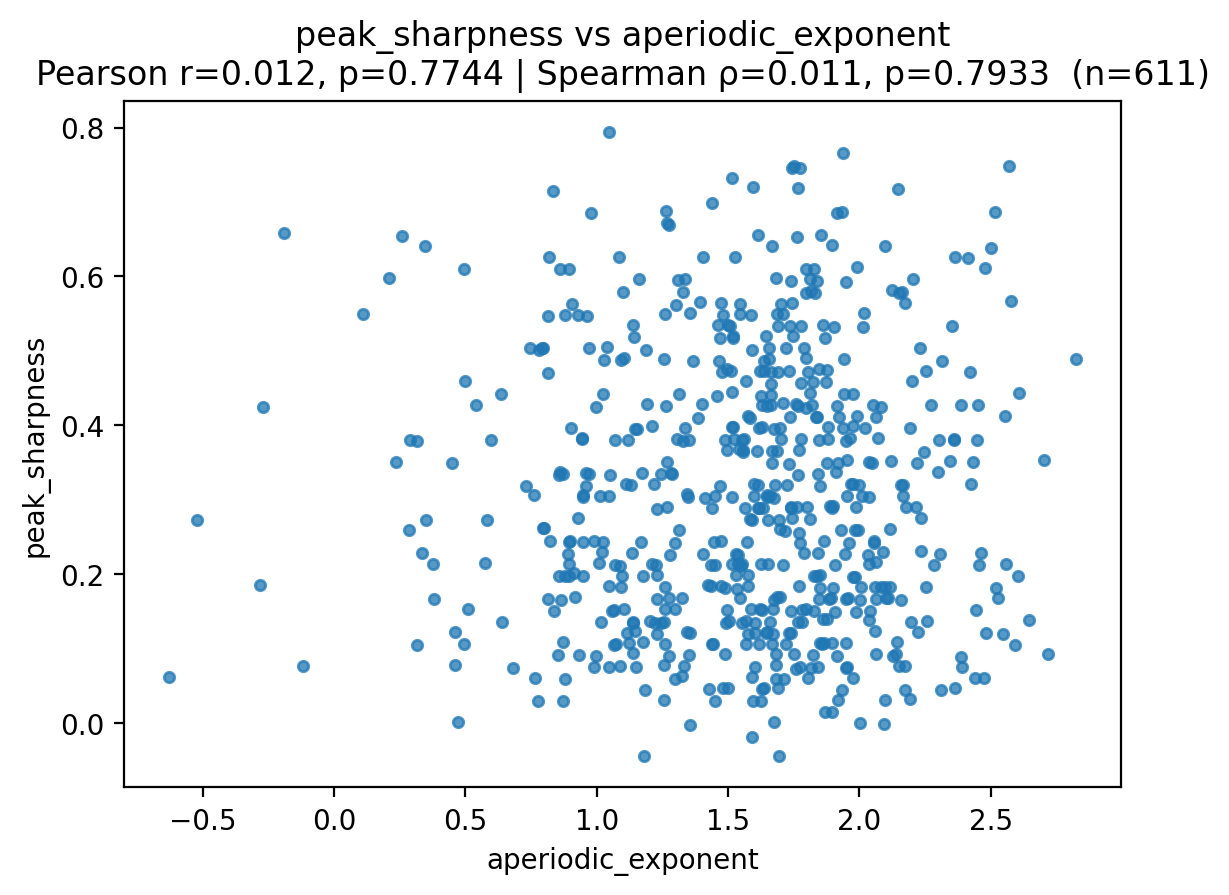

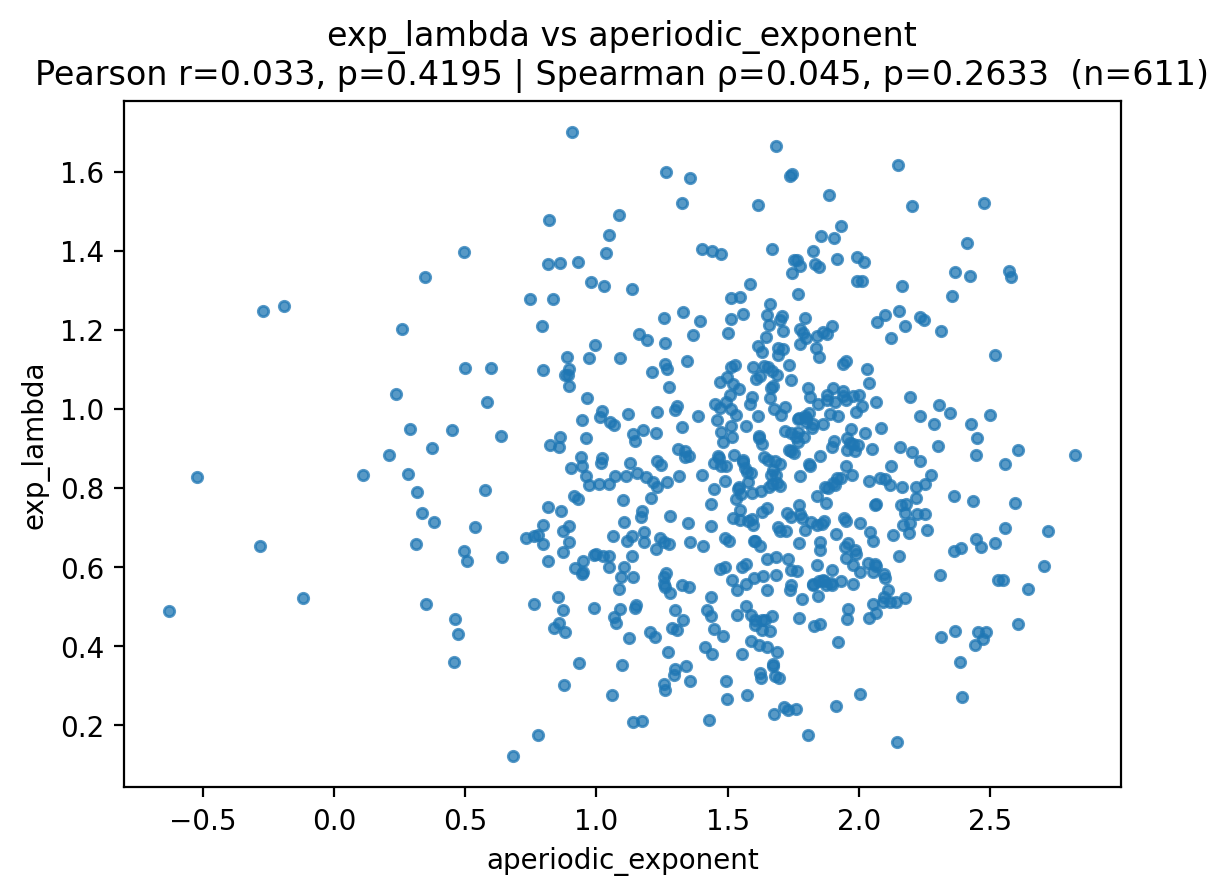

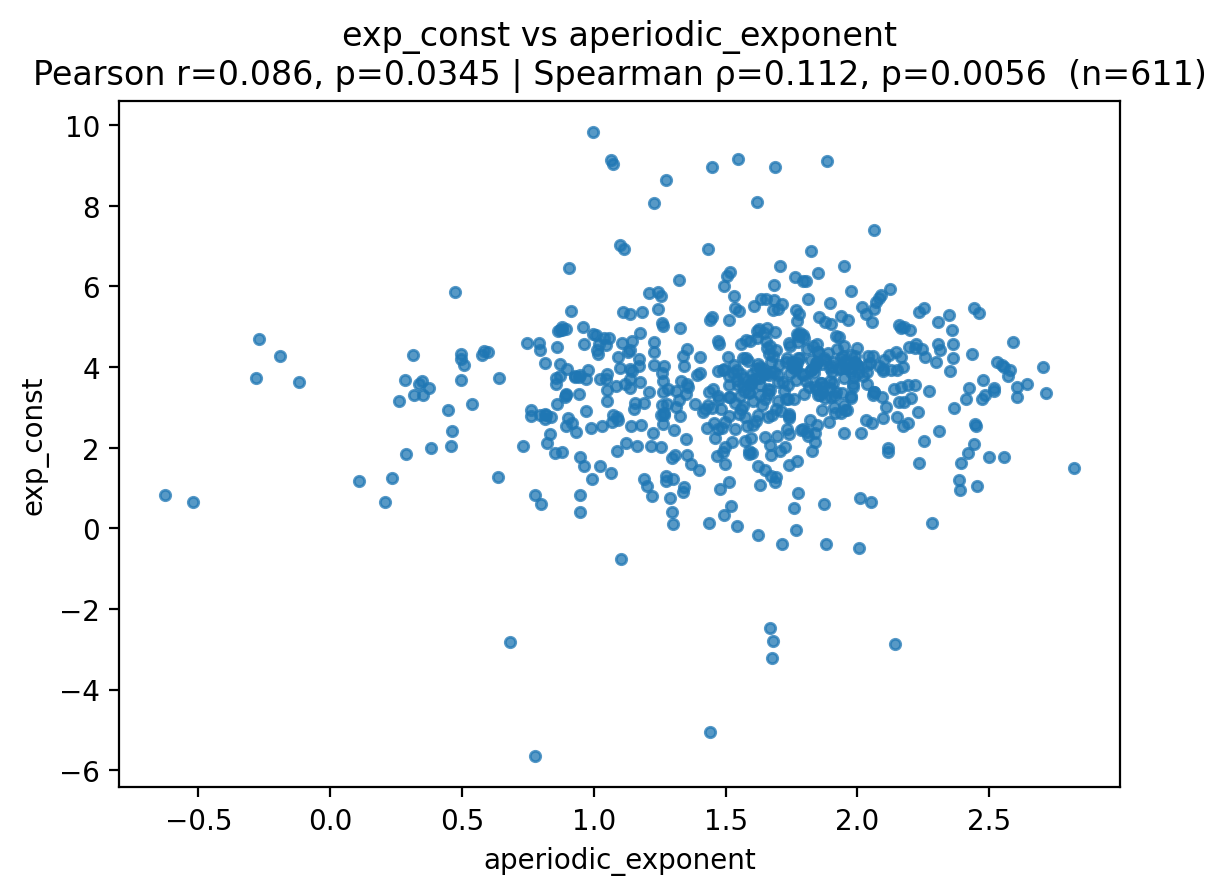

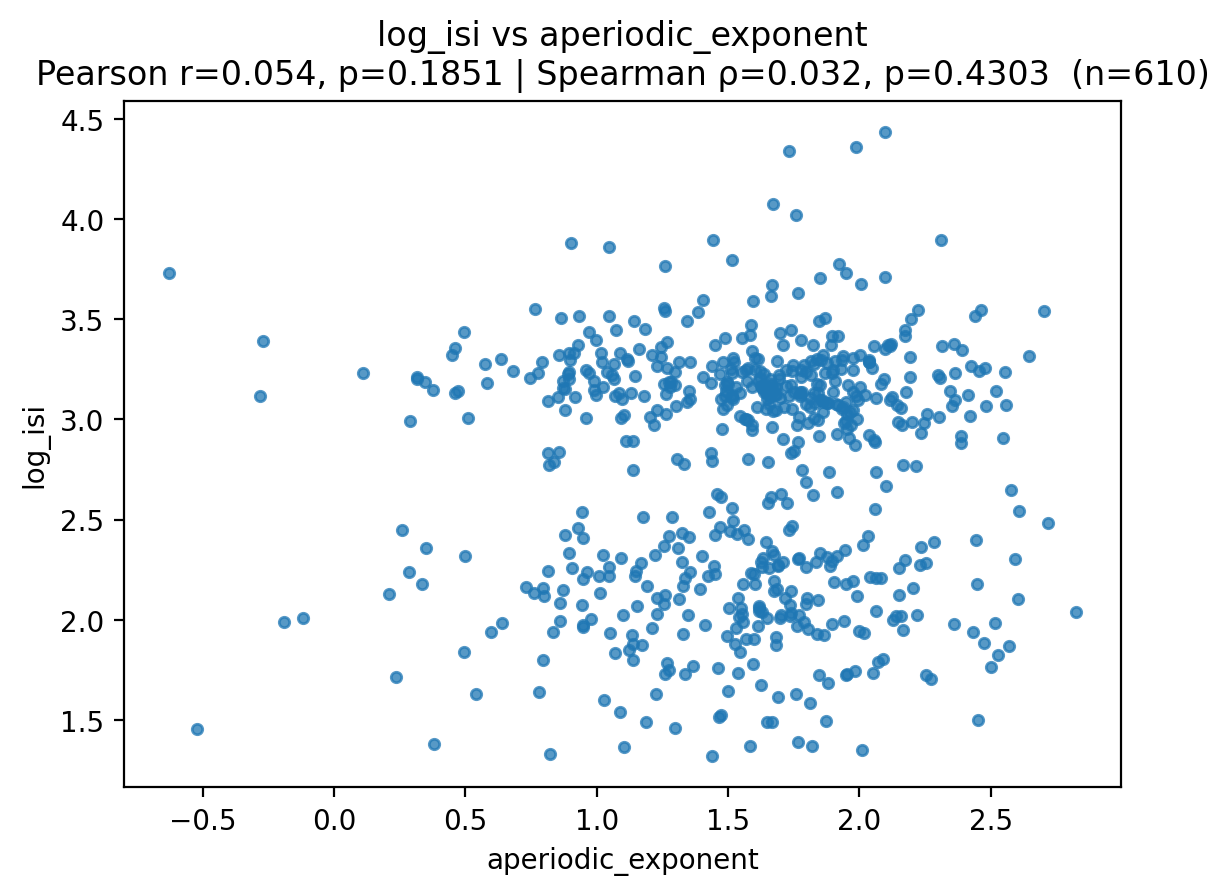

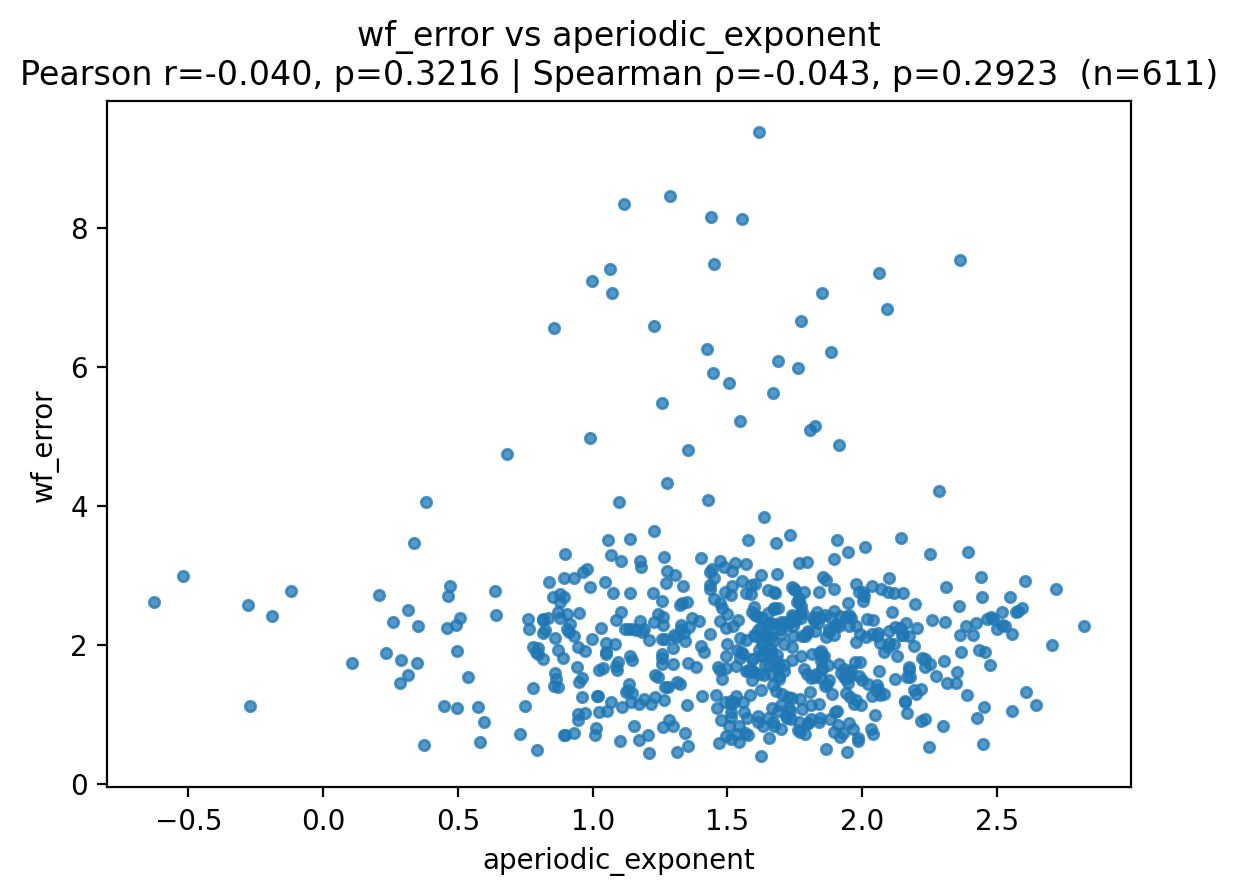

In [386]:
#look for correlations 

from scipy.stats import pearsonr, spearmanr

df = spike_lfp_with_feats  # your merged dataframe

lfp_feats   = ["gamma_auc", "aperiodic_exponent"]
spike_feats = [
    "ramp_amp","inflection_time","inflection_amp","peak_amp",
    "peak_width","peak_sharpness","exp_lambda","exp_const","log_isi","wf_error"
]

lfp_feats   = [c for c in lfp_feats   if c in df.columns]
spike_feats = [c for c in spike_feats if c in df.columns]

def fmt_p(p, decimals=4):
    thresh = 10**(-decimals)
    return f"< {thresh:.{decimals}f}" if p < thresh else f"{p:.{decimals}f}"

for x in lfp_feats:
    for y in spike_feats:
        d = df[[x, y]].dropna()
        n = len(d)
        if n < 3:
            continue

        r_p, p_p = pearsonr(d[x], d[y])
        r_s, p_s = spearmanr(d[x], d[y])

        fig, ax = plt.subplots(figsize=(5.8, 4.6))
        ax.scatter(d[x].to_numpy(), d[y].to_numpy(), s=14, alpha=0.75)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(
            f"{y} vs {x}\n"
            f"Pearson r={r_p:.3f}, p={fmt_p(p_p)} | "
            f"Spearman ρ={r_s:.3f}, p={fmt_p(p_s)}  (n={n})"
        )

       

        plt.tight_layout()
        plt.show()
